In [1]:
from __future__ import annotations

import os
import random
import json
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Callable, Optional, Tuple, List, Dict, Any

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
import torch.nn as nn
import wandb
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

/Users/jocareher/anaconda3/envs/lmks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Setting random seed for all source of randomness
def set_seed(seed_value: int=42) -> None:
    """
    Set the random seed for various libraries to ensure reproducibility.

    Args:
        seed_value (int): The random seed value to be used.

    Returns:
        None
    """

    # Setting the random seed for numpy's random number generator
    np.random.seed(seed_value)

    # Setting the random seed for PyTorch's random number generator and the CUDA random number generator
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

    # Setting the random seed for Python's built-in random library
    random.seed(seed_value)

seed_value = 42
set_seed(seed_value)

In [3]:
@dataclass
class Compose:
    """
    Compose multiple sample-level transforms.

    Parameters
    ----------
    transforms : list[Callable[[dict[str, Any]], dict[str, Any]]]
        List of transforms applied sequentially to the input sample.
    """

    transforms: List[Callable[[SampleDict], SampleDict]]

    def __call__(self, sample: SampleDict) -> SampleDict:
        """
        Apply all transforms sequentially.

        Parameters
        ----------
        sample : dict[str, Any]
            Input sample dictionary.

        Returns
        -------
        dict[str, Any]
            Transformed sample dictionary.
        """
        for transform in self.transforms:
            sample = transform(sample)
        return sample


@dataclass
class Resize:
    """
    Resize image and rescale landmark coordinates in pixel space.

    Parameters
    ----------
    size : tuple[int, int]
        Target size in the format (height, width).
    interpolation : int, optional
        PIL interpolation mode. Defaults to Image.BILINEAR.
    """

    size: Tuple[int, int]
    interpolation: int = Image.BILINEAR

    def __call__(self, sample: SampleDict) -> SampleDict:
        """
        Resize the image and rescale landmarks accordingly.

        Parameters
        ----------
        sample : dict[str, Any]
            Input sample containing image, landmarks, visibility, and metadata.

        Returns
        -------
        dict[str, Any]
            Updated sample with resized image and rescaled landmarks.
        """
        image = sample["image"]
        landmarks = sample["landmarks"]
        metadata = dict(sample.get("metadata", {}))

        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)

        if not isinstance(image, Image.Image):
            raise TypeError(f"Unsupported image type: {type(image)}.")

        original_width, original_height = image.size
        target_height, target_width = self.size

        scale_x = target_width / float(original_width)
        scale_y = target_height / float(original_height)

        resized_image = image.resize((target_width, target_height), self.interpolation)

        resized_landmarks = landmarks.copy()
        resized_landmarks[:, 0] *= scale_x
        resized_landmarks[:, 1] *= scale_y

        metadata["original_size"] = (original_height, original_width)
        metadata["transformed_size"] = (target_height, target_width)
        metadata["resize_scale"] = (scale_x, scale_y)

        sample["image"] = resized_image
        sample["landmarks"] = resized_landmarks
        sample["metadata"] = metadata

        return sample


@dataclass
class ToTensor:
    """
    Convert image, landmarks, and visibility to PyTorch tensors.

    The image is converted to float32 CHW format and scaled to [0, 1].
    Landmarks and visibility are converted to float32 tensors.
    """

    def __call__(self, sample: SampleDict) -> SampleDict:
        """
        Convert sample fields to tensors.

        Parameters
        ----------
        sample : dict[str, Any]
            Input sample dictionary.

        Returns
        -------
        dict[str, Any]
            Sample dictionary with tensor fields.
        """
        image = sample["image"]
        landmarks = sample["landmarks"]
        visibility = sample["visibility"]

        if isinstance(image, Image.Image):
            image = np.asarray(image)

        if not isinstance(image, np.ndarray):
            raise TypeError(f"Expected image as PIL image or numpy array, got {type(image)}.")

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).contiguous().float() / 255.0
        landmarks_tensor = torch.as_tensor(landmarks, dtype=torch.float32)
        visibility_tensor = torch.as_tensor(visibility, dtype=torch.float32)

        sample["image"] = image_tensor
        sample["landmarks"] = landmarks_tensor
        sample["visibility"] = visibility_tensor

        return sample


@dataclass
class Normalize:
    """
    Normalize an image tensor using channel-wise mean and standard deviation.

    Parameters
    ----------
    mean : tuple[float, float, float]
        Channel-wise mean values.
    std : tuple[float, float, float]
        Channel-wise standard deviation values.
    """

    mean: Tuple[float, float, float]
    std: Tuple[float, float, float]

    def __post_init__(self) -> None:
        """Prepare broadcastable normalization tensors."""
        self.mean_tensor = torch.tensor(self.mean, dtype=torch.float32).view(3, 1, 1)
        self.std_tensor = torch.tensor(self.std, dtype=torch.float32).view(3, 1, 1)

    def __call__(self, sample: SampleDict) -> SampleDict:
        """
        Normalize the image tensor.

        Parameters
        ----------
        sample : dict[str, Any]
            Input sample dictionary.

        Returns
        -------
        dict[str, Any]
            Updated sample dictionary with normalized image.
        """
        image = sample["image"]

        if not isinstance(image, torch.Tensor):
            raise TypeError(f"Expected image as torch.Tensor, got {type(image)}.")

        sample["image"] = (image - self.mean_tensor) / self.std_tensor
        return sample

@lru_cache(maxsize=32)
def build_gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """
    Build and cache a 2D Gaussian kernel with peak value 1.

    Parameters
    ----------
    size : int
        Kernel size. Must be odd.
    sigma : float
        Standard deviation of the Gaussian kernel.

    Returns
    -------
    np.ndarray
        Gaussian kernel of shape (size, size).
    """
    x = np.arange(0, size, dtype=np.float32)
    y = x[:, np.newaxis]
    center = size // 2
    kernel = np.exp(-((x - center) ** 2 + (y - center) ** 2) / (2.0 * sigma ** 2))
    return kernel.astype(np.float32)


def draw_gaussian(heatmap: np.ndarray, point: np.ndarray, sigma: float) -> np.ndarray:
    """
    Draw a truncated Gaussian patch onto a heatmap.

    Parameters
    ----------
    heatmap : np.ndarray
        Target heatmap of shape (H, W).
    point : np.ndarray
        Landmark location in heatmap coordinates as (x, y).
    sigma : float
        Standard deviation of the Gaussian.

    Returns
    -------
    np.ndarray
        Updated heatmap.
    """
    tmp_size = int(sigma * 3)
    x, y = float(point[0]), float(point[1])

    upper_left = [int(x - tmp_size), int(y - tmp_size)]
    bottom_right = [int(x + tmp_size + 1), int(y + tmp_size + 1)]

    if (
        upper_left[0] >= heatmap.shape[1]
        or upper_left[1] >= heatmap.shape[0]
        or bottom_right[0] < 0
        or bottom_right[1] < 0
    ):
        return heatmap

    size = 2 * tmp_size + 1
    gaussian = build_gaussian_kernel(size=size, sigma=sigma)

    gaussian_x = max(0, -upper_left[0]), min(bottom_right[0], heatmap.shape[1]) - upper_left[0]
    gaussian_y = max(0, -upper_left[1]), min(bottom_right[1], heatmap.shape[0]) - upper_left[1]

    image_x = max(0, upper_left[0]), min(bottom_right[0], heatmap.shape[1])
    image_y = max(0, upper_left[1]), min(bottom_right[1], heatmap.shape[0])

    heatmap[image_y[0]:image_y[1], image_x[0]:image_x[1]] = gaussian[
        gaussian_y[0]:gaussian_y[1], gaussian_x[0]:gaussian_x[1]
    ]
    return heatmap


class SyntheticLandmarkDataset(Dataset):
    """
    PyTorch dataset for synthetic facial landmark data.

    Expected directory structure
    ----------------------------
    root_dir/
        train/
            images/
            labels/
        val/
            images/
            labels/
        test/
            images/
            labels/

    Each label file must contain `num_landmarks` rows with three columns:
    `x y v`, where x and y are normalized coordinates in [0, 1], and v is
    a binary visibility flag.

    Internally, landmarks are converted to pixel coordinates using the original
    image size, then transformed in pixel space.

    This implementation keeps indexing intentionally lightweight:
    - it only checks that image and label files exist
    - optionally, it performs a minimal label-shape check
    - it supports optional .pth cache files to avoid re-indexing

    Parameters
    ----------
    root_dir : str | Path
        Root directory of the synthetic dataset.
    split : str
        Dataset split. Expected values are {"train", "val", "test"}.
    transform : Optional[Callable[[dict[str, Any]], dict[str, Any]]], optional
        External sample-level transform pipeline.
    target_mode : Literal["regression", "heatmap", "both"], optional
        Output target mode. Defaults to "heatmap".
    num_landmarks : int, optional
        Number of landmarks per sample. Defaults to 72.
    heatmap_size : tuple[int, int], optional
        Heatmap size in the format (height, width). Defaults to (64, 64).
    sigma : float, optional
        Gaussian sigma for heatmap generation. Defaults to 2.0.
    return_metadata : bool, optional
        Whether to return sample metadata. Defaults to True.
    validate_labels : bool, optional
        Whether to perform a minimal label-shape validation during indexing.
        Defaults to False.
    cache_file : Optional[str | Path], optional
        Optional .pth cache file. If provided and exists, samples are loaded
        from cache. If provided and missing, samples are indexed and saved there.
    use_cache : bool, optional
        Whether to use cache loading/saving logic. Defaults to True.
    show_progress : bool, optional
        Whether to show tqdm progress during indexing. Defaults to True.
    """

    def __init__(
        self,
        root_dir: str | Path,
        split: str,
        transform: Optional[Callable[[SampleDict], SampleDict]] = None,
        target_mode: TargetMode = "heatmap",
        num_landmarks: int = 72,
        heatmap_size: Tuple[int, int] = (64, 64),
        sigma: float = 2.0,
        return_metadata: bool = True,
        validate_labels: bool = False,
        cache_file: Optional[str | Path] = None,
        use_cache: bool = True,
        show_progress: bool = True,
    ) -> None:
        """
        Initialize the dataset.

        Raises
        ------
        FileNotFoundError
            If the image or label directories do not exist.
        ValueError
            If target_mode is invalid.
        RuntimeError
            If no valid samples are found.
        """
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform
        self.target_mode = target_mode
        self.num_landmarks = num_landmarks
        self.heatmap_size = heatmap_size
        self.sigma = sigma
        self.return_metadata = return_metadata
        self.validate_labels = validate_labels
        self.use_cache = use_cache
        self.show_progress = show_progress

        if self.target_mode not in {"regression", "heatmap", "both"}:
            raise ValueError(
                f"Invalid target_mode '{self.target_mode}'. "
                f"Expected one of: 'regression', 'heatmap', 'both'."
            )

        self.images_dir = self.root_dir / self.split / "images"
        self.labels_dir = self.root_dir / self.split / "labels"

        if not self.images_dir.exists():
            raise FileNotFoundError(f"Images directory not found: {self.images_dir}")

        if not self.labels_dir.exists():
            raise FileNotFoundError(f"Labels directory not found: {self.labels_dir}")

        if cache_file is None:
            self.cache_file = self.root_dir / f"{self.split}_samples_cache.pth"
        else:
            cache_path = Path(cache_file)
            if cache_path.suffix == "":
                cache_path = cache_path.with_suffix(".pth")
            self.cache_file = cache_path

        self.samples = self._load_or_build_samples()

        if not self.samples:
            raise RuntimeError(
                f"No valid samples found in split '{self.split}' under {self.root_dir}."
            )

    def __len__(self) -> int:
        """
        Return the number of indexed samples.

        Returns
        -------
        int
            Number of valid samples.
        """
        return len(self.samples)

    def __getitem__(self, index: int) -> SampleDict:
        """
        Load a sample and generate the requested targets.

        Parameters
        ----------
        index : int
            Sample index.

        Returns
        -------
        dict[str, Any]
            Dictionary containing image, visibility, optional landmarks,
            optional heatmaps, and optional metadata.
        """
        sample_info = self.samples[index]
        image_path = Path(sample_info["image_path"])
        label_path = Path(sample_info["label_path"])

        image = self._load_image(image_path)
        original_width, original_height = image.size

        landmarks, visibility = self._load_label(
            label_path=label_path,
            image_width=original_width,
            image_height=original_height,
        )

        metadata = {
            "sample_id": image_path.stem,
            "image_path": str(image_path),
            "label_path": str(label_path),
            "original_size": (original_height, original_width),
            "transformed_size": (original_height, original_width),
            "split": self.split,
            "num_landmarks": self.num_landmarks,
        }

        sample: SampleDict = {
            "image": image,
            "landmarks": landmarks,
            "visibility": visibility,
            "metadata": metadata,
        }

        if self.transform is not None:
            sample = self.transform(sample)

        image_tensor = self._ensure_image_tensor(sample["image"])
        landmarks_tensor = self._ensure_landmark_tensor(sample["landmarks"])
        visibility_tensor = self._ensure_visibility_tensor(sample["visibility"])

        output: SampleDict = {
            "image": image_tensor,
            "visibility": visibility_tensor,
        }

        if self.target_mode in {"regression", "both"}:
            output["landmarks"] = landmarks_tensor

        if self.target_mode in {"heatmap", "both"}:
            output["heatmaps"] = self._generate_heatmaps(
                landmarks=landmarks_tensor,
                image_size=sample["metadata"]["transformed_size"],
            )

        if self.return_metadata:
            output["metadata"] = sample.get("metadata", metadata)

        return output

    def _load_or_build_samples(self) -> List[Dict[str, str]]:
        """
        Load samples from cache if available and valid, otherwise build them.

        Returns
        -------
        list[dict[str, str]]
            Indexed sample list with image and label paths.
        """
        if self.use_cache and self.cache_file.exists():
            try:
                samples = self._load_cache()
                if samples:
                    return samples
            except Exception:
                pass

        samples = self._index_samples()

        if self.use_cache:
            self._save_cache(samples)

        return samples

    def _load_cache(self) -> List[Dict[str, str]]:
        """
        Load indexed samples from a .pth cache file.

        Returns
        -------
        list[dict[str, str]]
            Cached sample list.

        Raises
        ------
        ValueError
            If the cache content is invalid or incompatible.
        """
        payload = torch.load(
            self.cache_file,
            map_location="cpu",
            weights_only=False,
        )

        if not isinstance(payload, dict):
            raise ValueError(f"Invalid cache format in {self.cache_file}")

        cached_split = payload.get("split")
        cached_num_landmarks = payload.get("num_landmarks")
        samples = payload.get("samples")

        if cached_split != self.split:
            raise ValueError(
                f"Cache split mismatch in {self.cache_file}: "
                f"expected '{self.split}', got '{cached_split}'."
            )

        if cached_num_landmarks != self.num_landmarks:
            raise ValueError(
                f"Cache num_landmarks mismatch in {self.cache_file}: "
                f"expected {self.num_landmarks}, got {cached_num_landmarks}."
            )

        if not isinstance(samples, list):
            raise ValueError(f"Invalid 'samples' field in cache {self.cache_file}")

        return samples

    def _save_cache(self, samples: List[Dict[str, str]]) -> None:
        """
        Save indexed samples to a .pth cache file atomically.

        Parameters
        ----------
        samples : list[dict[str, str]]
            Sample list to serialize.
        """
        self.cache_file.parent.mkdir(parents=True, exist_ok=True)

        payload = {
            "split": self.split,
            "num_landmarks": self.num_landmarks,
            "samples": samples,
        }

        temp_cache_file = self.cache_file.with_suffix(self.cache_file.suffix + ".tmp")
        torch.save(payload, temp_cache_file)
        temp_cache_file.replace(self.cache_file)

    def _index_samples(self) -> List[Dict[str, str]]:
        """
        Index valid image-label pairs with minimal checks.

        Strategy
        --------
        - keep only image files that have a matching .txt label
        - optionally perform a minimal shape validation on the label
        - do not open images during indexing
        - do not perform expensive semantic validation

        Returns
        -------
        list[dict[str, str]]
            List of valid sample records containing image and label paths.
        """
        valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        image_paths = sorted(
            path for path in self.images_dir.iterdir()
            if path.suffix.lower() in valid_extensions
        )

        samples: List[Dict[str, str]] = []
        missing_labels = 0
        invalid_labels = 0

        iterator = image_paths
        progress_bar = None

        if self.show_progress:
            progress_bar = tqdm(
                image_paths,
                desc=f"Indexing {self.split}",
                unit="img",
                dynamic_ncols=True,
            )
            iterator = progress_bar

        for index, image_path in enumerate(iterator):
            label_path = self.labels_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                missing_labels += 1
                if progress_bar is not None and index % 100 == 0:
                    progress_bar.set_postfix(
                        valid=len(samples),
                        missing=missing_labels,
                        invalid=invalid_labels,
                    )
                continue

            if self.validate_labels and not self._is_minimally_valid_label(label_path):
                invalid_labels += 1
                if progress_bar is not None and index % 100 == 0:
                    progress_bar.set_postfix(
                        valid=len(samples),
                        missing=missing_labels,
                        invalid=invalid_labels,
                    )
                continue

            samples.append(
                {
                    "image_path": str(image_path),
                    "label_path": str(label_path),
                }
            )

            if progress_bar is not None and index % 100 == 0:
                progress_bar.set_postfix(
                    valid=len(samples),
                    missing=missing_labels,
                    invalid=invalid_labels,
                )

        if progress_bar is not None:
            progress_bar.set_postfix(
                valid=len(samples),
                missing=missing_labels,
                invalid=invalid_labels,
            )

        return samples

    def _is_minimally_valid_label(self, label_path: Path) -> bool:
        """
        Perform a minimal label check.

        This function only verifies that the file can be read and that it has
        shape (num_landmarks, 3). It intentionally avoids heavier validation.

        Parameters
        ----------
        label_path : Path
            Path to the label file.

        Returns
        -------
        bool
            True if the label passes the minimal check, otherwise False.
        """
        try:
            data = np.loadtxt(label_path, dtype=np.float32)
        except Exception:
            return False

        if data.ndim == 1:
            data = data.reshape(1, -1)

        return data.shape == (self.num_landmarks, 3)

    def _load_image(self, image_path: Path) -> Image.Image:
        """
        Load an RGB image.

        Parameters
        ----------
        image_path : Path
            Path to the image.

        Returns
        -------
        PIL.Image.Image
            RGB image.
        """
        return Image.open(image_path).convert("RGB")

    def _load_label(
        self,
        label_path: Path,
        image_width: int,
        image_height: int,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Load landmark coordinates and visibility from a label file.

        The label file stores normalized coordinates in [0, 1]. This method
        converts them to pixel coordinates in the original image space.

        Parameters
        ----------
        label_path : Path
            Path to the label file.
        image_width : int
            Original image width.
        image_height : int
            Original image height.

        Returns
        -------
        tuple[np.ndarray, np.ndarray]
            Landmarks with shape (N, 2) in pixel coordinates and visibility
            with shape (N,).

        Raises
        ------
        ValueError
            If the label file format is invalid.
        """
        data = np.loadtxt(label_path, dtype=np.float32)

        if data.ndim == 1:
            data = data.reshape(1, -1)

        if data.shape != (self.num_landmarks, 3):
            raise ValueError(
                f"Invalid label shape in '{label_path}'. "
                f"Expected ({self.num_landmarks}, 3), got {data.shape}."
            )

        landmarks = data[:, :2].astype(np.float32, copy=True)
        visibility = data[:, 2].astype(np.float32, copy=True)

        landmarks[:, 0] *= float(image_width)
        landmarks[:, 1] *= float(image_height)

        return landmarks, visibility

    def _ensure_image_tensor(self, image: Any) -> torch.Tensor:
        """
        Ensure the image is a float32 torch tensor in CHW format.

        Parameters
        ----------
        image : Any
            Image as torch tensor, PIL image, or numpy array.

        Returns
        -------
        torch.Tensor
            Image tensor with shape (3, H, W).
        """
        if isinstance(image, torch.Tensor):
            return image.float()

        if isinstance(image, Image.Image):
            image = np.asarray(image)

        if isinstance(image, np.ndarray):
            return torch.from_numpy(image).permute(2, 0, 1).contiguous().float() / 255.0

        raise TypeError(f"Unsupported image type: {type(image)}.")

    def _ensure_landmark_tensor(self, landmarks: Any) -> torch.Tensor:
        """
        Ensure landmarks are a float32 tensor of shape (N, 2).

        Parameters
        ----------
        landmarks : Any
            Landmark array or tensor.

        Returns
        -------
        torch.Tensor
            Landmark tensor.

        Raises
        ------
        ValueError
            If landmark shape is invalid.
        """
        landmarks_tensor = torch.as_tensor(landmarks, dtype=torch.float32)

        if landmarks_tensor.ndim != 2 or landmarks_tensor.shape[1] != 2:
            raise ValueError(
                f"Expected landmarks with shape (N, 2), got {tuple(landmarks_tensor.shape)}."
            )

        return landmarks_tensor

    def _ensure_visibility_tensor(self, visibility: Any) -> torch.Tensor:
        """
        Ensure visibility is a float32 tensor of shape (N,).

        Parameters
        ----------
        visibility : Any
            Visibility array or tensor.

        Returns
        -------
        torch.Tensor
            Visibility tensor.

        Raises
        ------
        ValueError
            If visibility shape is invalid.
        """
        visibility_tensor = torch.as_tensor(visibility, dtype=torch.float32)

        if visibility_tensor.ndim != 1 or visibility_tensor.shape[0] != self.num_landmarks:
            raise ValueError(
                f"Expected visibility with shape ({self.num_landmarks},), "
                f"got {tuple(visibility_tensor.shape)}."
            )

        return visibility_tensor

    def _generate_heatmaps(
        self,
        landmarks: torch.Tensor,
        image_size: Tuple[int, int],
    ) -> torch.Tensor:
        """
        Generate Gaussian heatmaps using the local truncated strategy from HRNet.

        Parameters
        ----------
        landmarks : torch.Tensor
            Landmark tensor with shape (N, 2) in pixel coordinates of the
            transformed image space.
        image_size : tuple[int, int]
            Transformed image size as (height, width).

        Returns
        -------
        torch.Tensor
            Heatmap tensor with shape (N, Hh, Wh).
        """
        image_height, image_width = image_size
        heatmap_height, heatmap_width = self.heatmap_size

        scale_x = heatmap_width / float(image_width)
        scale_y = heatmap_height / float(image_height)

        landmarks_np = landmarks.detach().cpu().numpy().astype(np.float32, copy=True)
        heatmaps = np.zeros(
            (self.num_landmarks, heatmap_height, heatmap_width),
            dtype=np.float32,
        )

        for landmark_index in range(self.num_landmarks):
            point = landmarks_np[landmark_index].copy()
            point[0] *= scale_x
            point[1] *= scale_y
            heatmaps[landmark_index] = draw_gaussian(
                heatmap=heatmaps[landmark_index],
                point=point,
                sigma=self.sigma,
            )

        return torch.from_numpy(heatmaps)

In [4]:
# Define transformations for training and validation datasets
train_transform = Compose(
    transforms=[
        Resize(size=(256, 256)),
        ToTensor(),
        Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
    ]
)

val_transform = Compose(
    transforms=[
        Resize(size=(256, 256)),
        ToTensor(),
        Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
    ]
)

# Create the training dataset
train_dataset = SyntheticLandmarkDataset(
    root_dir="../data/synthetic_lmks_vis_dataset",
    split="train",
    transform=train_transform,
    target_mode="both",
    validate_labels=False,
    cache_file="train_cache.pth",
    use_cache=True,
)
val_dataset = SyntheticLandmarkDataset(
    root_dir="../data/synthetic_lmks_vis_dataset",
    split="val",
    transform=val_transform,
    target_mode="both",
    validate_labels=False,
    cache_file="val_cache.pth",
    use_cache=True,
)
test_dataset = SyntheticLandmarkDataset(
    root_dir="../data/synthetic_lmks_vis_dataset",
    split="test",
    transform=val_transform,
    target_mode="both",
    validate_labels=False,
    cache_file="test_cache.pth",
    use_cache=True,
)

sample = train_dataset[0]

print("Keys:", sample.keys())
print("Image shape:", sample["image"].shape)
print("Visibility shape:", sample["visibility"].shape)

if "landmarks" in sample:
    print("Landmarks shape:", sample["landmarks"].shape)

if "heatmaps" in sample:
    print("Heatmaps shape:", sample["heatmaps"].shape)

if "metadata" in sample:
    print("Metadata:", sample["metadata"])




Keys: dict_keys(['image', 'visibility', 'landmarks', 'heatmaps', 'metadata'])
Image shape: torch.Size([3, 256, 256])
Visibility shape: torch.Size([72])
Landmarks shape: torch.Size([72, 2])
Heatmaps shape: torch.Size([72, 64, 64])
Metadata: {'sample_id': 'synthetic_shape_00001_frontal', 'image_path': '../data/synthetic_lmks_vis_dataset/train/images/synthetic_shape_00001_frontal.jpg', 'label_path': '../data/synthetic_lmks_vis_dataset/train/labels/synthetic_shape_00001_frontal.txt', 'original_size': (2372, 2627), 'transformed_size': (256, 256), 'split': 'train', 'num_landmarks': 72, 'resize_scale': (0.09744956223829464, 0.10792580101180438)}


/var/folders/vq/s72bqs6n3xdb85wdvyfzlnwc0000gn/T/ipykernel_15497/1822773255.py:129: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  image_tensor = torch.from_numpy(image).permute(2, 0, 1).contiguous().float() / 255.0


In [5]:
# Create the DataLoader for the training dataset
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16,  # Adjust batch size as needed
    shuffle=True,  # Shuffle the data
    num_workers=0  # Number of subprocesses for data loading
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=16,  # Adjust batch size as needed
    shuffle=False,  # No need to shuffle validation data
    num_workers=0  # Number of subprocesses for data loading
)

In [7]:
import math
import torch.nn.functional as F

def denormalize_image_tensor(
    image: torch.Tensor,
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float] = (0.229, 0.224, 0.225),
) -> torch.Tensor:
    """
    Denormalize an image tensor using channel-wise mean and standard deviation.

    Parameters
    ----------
    image : torch.Tensor
        Image tensor of shape (C, H, W).
    mean : Sequence[float], optional
        Channel-wise mean values. Defaults to ImageNet mean.
    std : Sequence[float], optional
        Channel-wise standard deviation values. Defaults to ImageNet std.

    Returns
    -------
    torch.Tensor
        Denormalized image tensor of shape (C, H, W).
    """
    if image.ndim != 3:
        raise ValueError(f"Expected image with shape (C, H, W), got {tuple(image.shape)}.")

    mean_tensor = torch.tensor(mean, dtype=image.dtype, device=image.device).view(-1, 1, 1)
    std_tensor = torch.tensor(std, dtype=image.dtype, device=image.device).view(-1, 1, 1)

    return image.clone() * std_tensor + mean_tensor


def _make_axes_grid(num_items: int, ncols: int, figsize_per_axis: float = 4.0):
    """
    Create a matplotlib grid with a configurable number of columns.

    Parameters
    ----------
    num_items : int
        Number of plots required.
    ncols : int
        Number of columns in the grid.
    figsize_per_axis : float, optional
        Size factor per subplot axis. Defaults to 4.0.

    Returns
    -------
    tuple[matplotlib.figure.Figure, np.ndarray]
        Figure and flattened axes array.
    """
    nrows = math.ceil(num_items / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * figsize_per_axis, nrows * figsize_per_axis),
    )

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])

    return fig, axes


def _plot_landmarks_on_axis(
    axis,
    image_np: np.ndarray,
    landmarks: Optional[torch.Tensor],
    visibility: Optional[torch.Tensor],
    title: str = "",
    show_indices: bool = False,
    visible_color: str = "lime",
    invisible_color: str = "red",
    marker_size: float = 12.0,
    text_fontsize: int = 7,
) -> None:
    """
    Plot an image and overlay landmarks on a matplotlib axis.

    Parameters
    ----------
    axis : matplotlib axis
        Axis where the image and landmarks will be drawn.
    image_np : np.ndarray
        Image array of shape (H, W, C) in [0, 1].
    landmarks : Optional[torch.Tensor]
        Landmark tensor of shape (N, 2) in pixel coordinates.
    visibility : Optional[torch.Tensor]
        Visibility tensor of shape (N,).
    title : str, optional
        Axis title. Defaults to "".
    show_indices : bool, optional
        Whether to write the landmark index next to each point. Defaults to False.
    visible_color : str, optional
        Color for visible landmarks. Defaults to "lime".
    invisible_color : str, optional
        Color for invisible landmarks. Defaults to "red".
    marker_size : float, optional
        Scatter marker size. Defaults to 12.0.
    text_fontsize : int, optional
        Font size for landmark indices. Defaults to 7.
    """
    axis.imshow(image_np)
    axis.set_title(title)
    axis.axis("off")

    if landmarks is None:
        return

    landmarks_np = landmarks.detach().cpu().numpy()
    visibility_np = visibility.detach().cpu().numpy() if visibility is not None else None

    for landmark_index, (x_coord, y_coord) in enumerate(landmarks_np):
        is_visible = True if visibility_np is None else visibility_np[landmark_index] > 0.5
        color = visible_color if is_visible else invisible_color
        alpha = 0.95 if is_visible else 0.65

        axis.scatter(x_coord, y_coord, c=color, s=marker_size, alpha=alpha)

        if show_indices:
            axis.text(
                x_coord + 2,
                y_coord + 2,
                str(landmark_index),
                color=color,
                fontsize=text_fontsize,
                bbox={"facecolor": "black", "alpha": 0.35, "pad": 1},
            )


def show_dataset_sample(
    dataset,
    index: int,
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float] = (0.229, 0.224, 0.225),
    show_heatmaps: bool = True,
    heatmap_landmark_index: Optional[int] = None,
    show_indices: bool = False,
    figsize_per_axis: float = 5.0,
) -> None:
    """
    Visualize a single sample directly from the dataset.

    Parameters
    ----------
    dataset : Dataset
        Dataset instance.
    index : int
        Sample index.
    mean : Sequence[float], optional
        Mean used for normalization.
    std : Sequence[float], optional
        Std used for normalization.
    show_heatmaps : bool, optional
        Whether to show heatmaps if available. Defaults to True.
    heatmap_landmark_index : Optional[int], optional
        Specific heatmap index to display. If None, show the sum of heatmaps.
    show_indices : bool, optional
        Whether to draw landmark indices. Defaults to False.
    figsize_per_axis : float, optional
        Figure size factor per axis. Defaults to 5.0.
    """
    sample = dataset[index]

    image = sample["image"].detach().cpu()
    image = denormalize_image_tensor(image, mean=mean, std=std)
    image_np = image.permute(1, 2, 0).clamp(0, 1).numpy()

    landmarks = sample.get("landmarks", None)
    visibility = sample.get("visibility", None)
    heatmaps = sample.get("heatmaps", None)
    metadata = sample.get("metadata", None)

    num_cols = 2 if (show_heatmaps and heatmaps is not None) else 1
    fig, axes = _make_axes_grid(num_items=num_cols, ncols=num_cols, figsize_per_axis=figsize_per_axis)

    title = f"Sample {index}"
    if metadata is not None and "sample_id" in metadata:
        title += f" | {metadata['sample_id']}"

    _plot_landmarks_on_axis(
        axis=axes[0],
        image_np=image_np,
        landmarks=landmarks,
        visibility=visibility,
        title=title,
        show_indices=show_indices,
    )

    if show_heatmaps and heatmaps is not None:
        heatmaps_cpu = heatmaps.detach().cpu()

        if heatmap_landmark_index is None:
            heatmap_to_show = heatmaps_cpu.sum(dim=0)
            heatmap_title = "Summed heatmaps"
        else:
            if not (0 <= heatmap_landmark_index < heatmaps_cpu.shape[0]):
                raise ValueError(
                    f"heatmap_landmark_index={heatmap_landmark_index} is out of range "
                    f"for {heatmaps_cpu.shape[0]} landmarks."
                )
            heatmap_to_show = heatmaps_cpu[heatmap_landmark_index]
            heatmap_title = f"Heatmap #{heatmap_landmark_index}"

        axes[1].imshow(heatmap_to_show.numpy(), cmap="jet")
        axes[1].set_title(heatmap_title)
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def show_batch_with_landmarks(
    dataloader: DataLoader,
    num_images: int = 8,
    grid_cols: int = 4,
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float] = (0.229, 0.224, 0.225),
    show_indices: bool = False,
    figsize_per_axis: float = 4.0,
) -> None:
    """
    Visualize a batch of images with all landmarks overlaid in a configurable grid.

    This function is intended primarily for regression-mode inspection or for
    datasets that return both landmarks and heatmaps. It displays the resized
    image tensor directly, so the plotted image size corresponds to the output
    of your transform pipeline, e.g. 256x256.

    Parameters
    ----------
    dataloader : DataLoader
        DataLoader that returns dictionary batches from the dataset.
    num_images : int, optional
        Number of images to display from the first batch. Defaults to 8.
    grid_cols : int, optional
        Number of columns in the visualization grid. Defaults to 4.
    mean : Sequence[float], optional
        Mean used for normalization. Defaults to ImageNet mean.
    std : Sequence[float], optional
        Std used for normalization. Defaults to ImageNet std.
    show_indices : bool, optional
        Whether to display landmark indices. Defaults to False.
    figsize_per_axis : float, optional
        Figure size factor per subplot. Defaults to 4.0.

    Raises
    ------
    ValueError
        If the dataloader batch does not contain images.
    """
    batch = next(iter(dataloader))

    if not isinstance(batch, dict):
        raise ValueError(
            "Expected dataloader to return a dictionary batch. "
            f"Got type: {type(batch)}"
        )

    images = batch.get("image", None)
    landmarks = batch.get("landmarks", None)
    visibility = batch.get("visibility", None)
    metadata = batch.get("metadata", None)

    if images is None:
        raise ValueError("Batch does not contain 'image'.")

    num_images = min(num_images, images.shape[0])

    fig, axes = _make_axes_grid(
        num_items=num_images,
        ncols=grid_cols,
        figsize_per_axis=figsize_per_axis,
    )

    for image_index in range(num_images):
        image_tensor = images[image_index].detach().cpu()
        image_tensor = denormalize_image_tensor(image_tensor, mean=mean, std=std)
        image_np = image_tensor.permute(1, 2, 0).clamp(0, 1).numpy()

        title = f"Sample {image_index}"

        if metadata is not None and isinstance(metadata, dict):
            sample_ids = metadata.get("sample_id", None)
            if sample_ids is not None:
                title = str(sample_ids[image_index])

        current_landmarks = landmarks[image_index] if landmarks is not None else None
        current_visibility = visibility[image_index] if visibility is not None else None

        _plot_landmarks_on_axis(
            axis=axes[image_index],
            image_np=image_np,
            landmarks=current_landmarks,
            visibility=current_visibility,
            title=title,
            show_indices=show_indices,
        )

    for axis_index in range(num_images, len(axes)):
        axes[axis_index].axis("off")

    plt.tight_layout()
    plt.show()


def _resize_heatmap_to_image(
    heatmap: torch.Tensor,
    image_height: int,
    image_width: int,
) -> np.ndarray:
    """
    Resize a single heatmap to the image spatial resolution.

    Parameters
    ----------
    heatmap : torch.Tensor
        Heatmap tensor of shape (Hh, Wh).
    image_height : int
        Target image height.
    image_width : int
        Target image width.

    Returns
    -------
    np.ndarray
        Resized heatmap as a numpy array of shape (image_height, image_width).
    """
    if heatmap.ndim != 2:
        raise ValueError(f"Expected heatmap with shape (H, W), got {tuple(heatmap.shape)}.")

    resized_heatmap = F.interpolate(
        heatmap.unsqueeze(0).unsqueeze(0),
        size=(image_height, image_width),
        mode="bilinear",
        align_corners=False,
    )

    return resized_heatmap.squeeze(0).squeeze(0).cpu().numpy()


def show_batch_heatmaps(
    dataloader: DataLoader,
    num_images: int = 8,
    grid_cols: int = 4,
    heatmap_landmark_index: Optional[int] = None,
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float] = (0.229, 0.224, 0.225),
    overlay_alpha: float = 0.45,
    use_max_projection: bool = True,
    normalize_heatmap: bool = True,
    figsize_per_axis: float = 4.0,
) -> None:
    """
    Visualize heatmaps overlaid on the corresponding resized images.

    Parameters
    ----------
    dataloader : DataLoader
        DataLoader that returns dictionary batches from the dataset.
    num_images : int, optional
        Number of samples to display. Defaults to 8.
    grid_cols : int, optional
        Number of columns in the visualization grid. Defaults to 4.
    heatmap_landmark_index : Optional[int], optional
        Specific landmark heatmap index to display. If None, all heatmaps are
        aggregated into a single map for display.
    mean : Sequence[float], optional
        Mean used during image normalization.
    std : Sequence[float], optional
        Standard deviation used during image normalization.
    overlay_alpha : float, optional
        Transparency of the heatmap overlay. Defaults to 0.45.
    use_max_projection : bool, optional
        If True, aggregate all heatmaps using max projection when
        heatmap_landmark_index is None. If False, use sum projection.
    normalize_heatmap : bool, optional
        Whether to normalize the displayed heatmap to [0, 1]. Defaults to True.
    figsize_per_axis : float, optional
        Figure size factor per subplot. Defaults to 4.0.

    Raises
    ------
    ValueError
        If the batch does not contain required fields.
    """
    batch = next(iter(dataloader))

    if not isinstance(batch, dict):
        raise ValueError(
            "Expected dataloader to return a dictionary batch. "
            f"Got type: {type(batch)}"
        )

    images = batch.get("image", None)
    heatmaps = batch.get("heatmaps", None)
    metadata = batch.get("metadata", None)

    if images is None:
        raise ValueError("Batch does not contain 'image'.")

    if heatmaps is None:
        raise ValueError(
            "Batch does not contain 'heatmaps'. "
            "Make sure the dataset uses target_mode='heatmap' or 'both'."
        )

    num_images = min(num_images, images.shape[0])

    fig, axes = _make_axes_grid(
        num_items=num_images,
        ncols=grid_cols,
        figsize_per_axis=figsize_per_axis,
    )

    for image_index in range(num_images):
        image_tensor = images[image_index].detach().cpu()
        image_tensor = denormalize_image_tensor(image_tensor, mean=mean, std=std)
        image_np = image_tensor.permute(1, 2, 0).clamp(0, 1).numpy()

        image_height, image_width = image_np.shape[:2]
        heatmaps_cpu = heatmaps[image_index].detach().cpu()

        if heatmap_landmark_index is None:
            if use_max_projection:
                heatmap_to_show = heatmaps_cpu.max(dim=0).values
            else:
                heatmap_to_show = heatmaps_cpu.sum(dim=0)
        else:
            if not (0 <= heatmap_landmark_index < heatmaps_cpu.shape[0]):
                raise ValueError(
                    f"heatmap_landmark_index={heatmap_landmark_index} is out of range "
                    f"for {heatmaps_cpu.shape[0]} landmarks."
                )
            heatmap_to_show = heatmaps_cpu[heatmap_landmark_index]

        heatmap_np = _resize_heatmap_to_image(
            heatmap=heatmap_to_show,
            image_height=image_height,
            image_width=image_width,
        )

        if normalize_heatmap:
            heatmap_min = float(heatmap_np.min())
            heatmap_max = float(heatmap_np.max())
            if heatmap_max > heatmap_min:
                heatmap_np = (heatmap_np - heatmap_min) / (heatmap_max - heatmap_min)

        axis = axes[image_index]
        axis.imshow(image_np)
        axis.imshow(heatmap_np, cmap="jet", alpha=overlay_alpha)
        axis.axis("off")

        title = ""
        if metadata is not None and isinstance(metadata, dict):
            sample_ids = metadata.get("sample_id", None)
            if sample_ids is not None:
                title = str(sample_ids[image_index])

        axis.set_title(title, fontsize=10)

    for axis_index in range(num_images, len(axes)):
        axes[axis_index].axis("off")

    plt.tight_layout()
    plt.show()


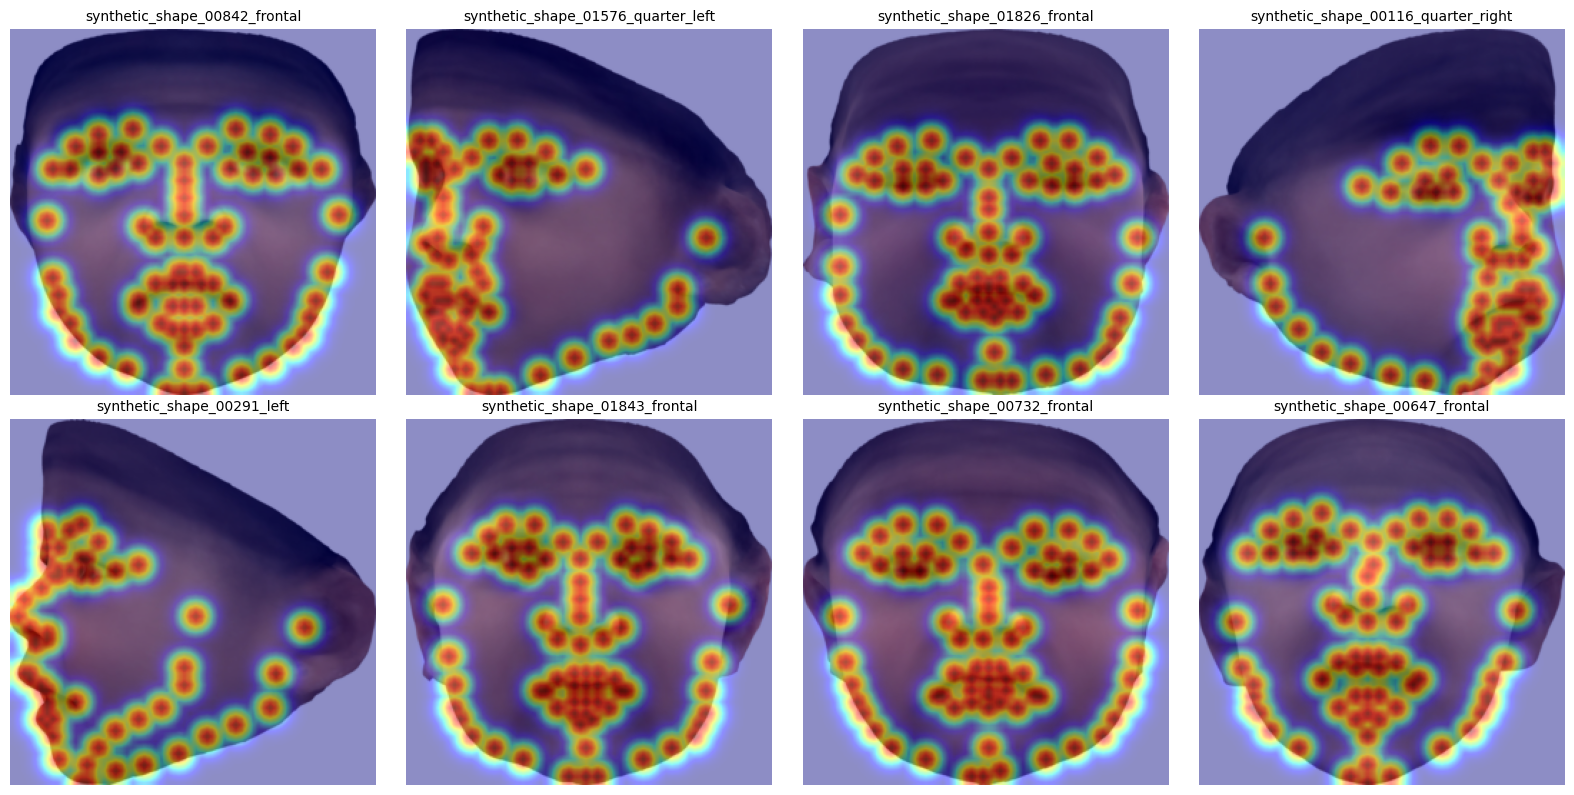

In [30]:
# Assuming train_loader is already defined from the previous Dataset and DataLoader
show_batch_heatmaps(
    dataloader=train_loader,
    num_images=8,
    grid_cols=4,
    heatmap_landmark_index=None,
)

In [8]:
def show_dataset_sample(
    dataset,
    index: int,
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float] = (0.229, 0.224, 0.225),
    show_heatmaps: bool = True,
    heatmap_landmark_index: Optional[int] = None,
) -> None:
    """
    Visualize a single sample directly from the dataset.

    Parameters
    ----------
    dataset : Dataset
        Dataset instance.
    index : int
        Sample index.
    mean : Sequence[float], optional
        Mean used for normalization.
    std : Sequence[float], optional
        Std used for normalization.
    show_heatmaps : bool, optional
        Whether to show heatmaps if available.
    heatmap_landmark_index : Optional[int], optional
        Specific heatmap index to display. If None, show the sum of heatmaps.
    """
    sample = dataset[index]

    image = sample["image"].detach().cpu()
    image = denormalize_image_tensor(image, mean=mean, std=std)
    image_np = image.permute(1, 2, 0).clamp(0, 1).numpy()

    landmarks = sample.get("landmarks", None)
    visibility = sample.get("visibility", None)
    heatmaps = sample.get("heatmaps", None)
    metadata = sample.get("metadata", None)

    num_cols = 2 if (show_heatmaps and heatmaps is not None) else 1
    fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 6))

    if num_cols == 1:
        axes = [axes]

    axes[0].imshow(image_np)
    axes[0].axis("off")

    title = f"Sample {index}"
    if metadata is not None and "sample_id" in metadata:
        title += f" | {metadata['sample_id']}"
    axes[0].set_title(title)

    if landmarks is not None:
        landmarks_np = landmarks.detach().cpu().numpy()
        visibility_np = visibility.detach().cpu().numpy() if visibility is not None else None

        for landmark_id, (x_coord, y_coord) in enumerate(landmarks_np):
            is_visible = True if visibility_np is None else visibility_np[landmark_id] > 0.5
            color = "lime" if is_visible else "red"
            axes[0].scatter(x_coord, y_coord, c=color, s=12, alpha=0.9 if is_visible else 0.6)

    if show_heatmaps and heatmaps is not None:
        heatmaps_cpu = heatmaps.detach().cpu()

        if heatmap_landmark_index is None:
            heatmap_to_show = heatmaps_cpu.sum(dim=0)
            heatmap_title = "Summed heatmaps"
        else:
            heatmap_to_show = heatmaps_cpu[heatmap_landmark_index]
            heatmap_title = f"Heatmap #{heatmap_landmark_index}"

        axes[1].imshow(heatmap_to_show.numpy(), cmap="jet")
        axes[1].axis("off")
        axes[1].set_title(heatmap_title)

    plt.tight_layout()
    plt.show()


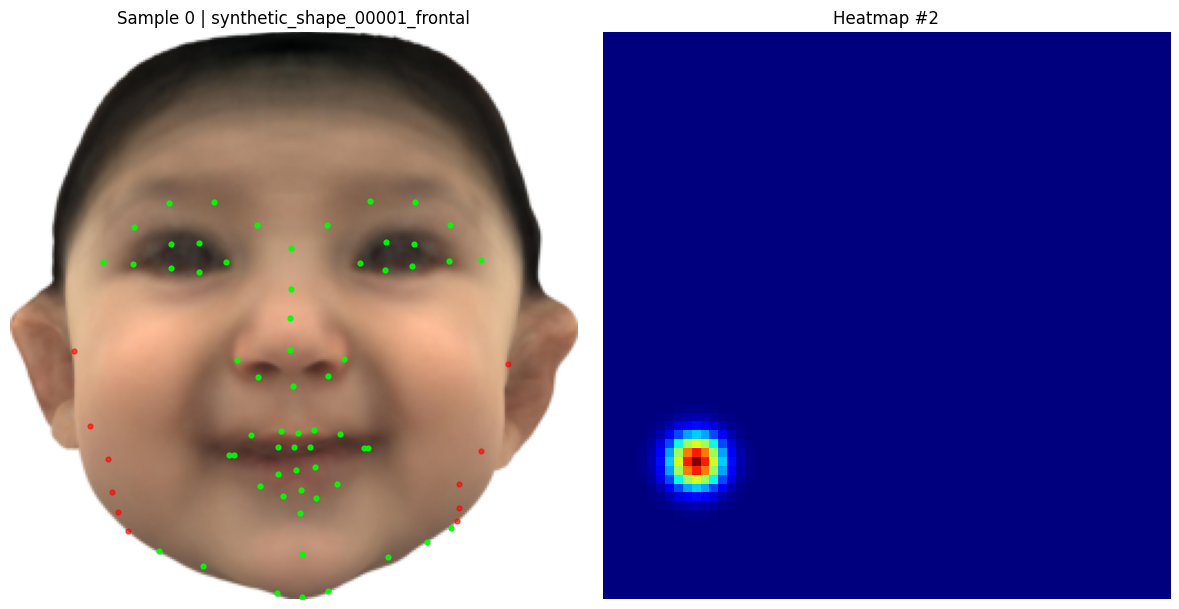

In [9]:
show_dataset_sample(train_dataset, index=0, show_heatmaps=True, heatmap_landmark_index=2)

In [10]:
def get_default_device() -> torch.device:
    """
    Determines and returns the default device for PyTorch computations.

    This function checks for the availability of CUDA (for NVIDIA GPUs), 
    MPS (for Apple's Sillicon chips), or defaults to CPU if none are available.

    Returns:
        A torch.device object representing the default device. If CUDA is available, 
        it will return a CUDA device, if MPS is available it will return an MPS device, 
        and if neither are available, it will return a CPU device.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")


device = get_default_device()
device

device(type='cpu')

In [11]:
from __future__ import annotations

import logging
import os
from typing import Dict, List, Literal, Optional, Sequence, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F


BatchNorm2d = nn.BatchNorm2d
BN_MOMENTUM = 0.01
TransferMode = Literal["feature_extractor", "fine_tuning"]


def conv3x3(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """
    Create a 3x3 convolution with padding.

    Parameters
    ----------
    in_planes : int
        Number of input channels.
    out_planes : int
        Number of output channels.
    stride : int, optional
        Convolution stride. Defaults to 1.

    Returns
    -------
    nn.Conv2d
        Configured convolution layer.
    """
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False,
    )


class BasicBlock(nn.Module):
    """
    Basic residual block used by HRNet.
    """

    expansion = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
    ) -> None:
        """
        Initialize the residual block.

        Parameters
        ----------
        inplanes : int
            Number of input channels.
        planes : int
            Number of internal channels.
        stride : int, optional
            Convolution stride. Defaults to 1.
        downsample : Optional[nn.Module], optional
            Residual projection branch. Defaults to None.
        """
        super().__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.downsample = downsample

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply the block.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor.

        Returns
        -------
        torch.Tensor
            Output tensor.
        """
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out = out + residual
        out = self.relu(out)
        return out


class Bottleneck(nn.Module):
    """
    Bottleneck residual block used in the HRNet stem layer.
    """

    expansion = 4

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
    ) -> None:
        """
        Initialize the bottleneck block.

        Parameters
        ----------
        inplanes : int
            Number of input channels.
        planes : int
            Number of internal channels.
        stride : int, optional
            Convolution stride. Defaults to 1.
        downsample : Optional[nn.Module], optional
            Residual projection branch. Defaults to None.
        """
        super().__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = BatchNorm2d(planes, momentum=BN_MOMENTUM)

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn2 = BatchNorm2d(planes, momentum=BN_MOMENTUM)

        self.conv3 = nn.Conv2d(
            planes,
            planes * self.expansion,
            kernel_size=1,
            bias=False,
        )
        self.bn3 = BatchNorm2d(planes * self.expansion, momentum=BN_MOMENTUM)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply the block.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor.

        Returns
        -------
        torch.Tensor
            Output tensor.
        """
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out = out + residual
        out = self.relu(out)
        return out


class HighResolutionModule(nn.Module):
    """
    Multi-branch HRNet module with feature fusion.
    """

    def __init__(
        self,
        num_branches: int,
        block: type[nn.Module],
        num_blocks: Sequence[int],
        num_inchannels: Sequence[int],
        num_channels: Sequence[int],
        fuse_method: str,
        multi_scale_output: bool = True,
    ) -> None:
        """
        Initialize the HRNet module.

        Parameters
        ----------
        num_branches : int
            Number of branches.
        block : type[nn.Module]
            Residual block type.
        num_blocks : Sequence[int]
            Number of blocks per branch.
        num_inchannels : Sequence[int]
            Input channels per branch.
        num_channels : Sequence[int]
            Internal channels per branch.
        fuse_method : str
            Fusion method name.
        multi_scale_output : bool, optional
            Whether to output all branch resolutions. Defaults to True.
        """
        super().__init__()
        self._check_branches(num_branches, num_blocks, num_inchannels, num_channels)

        self.num_inchannels = list(num_inchannels)
        self.num_branches = num_branches
        self.fuse_method = fuse_method
        self.multi_scale_output = multi_scale_output

        self.branches = self._make_branches(
            num_branches=num_branches,
            block=block,
            num_blocks=num_blocks,
            num_channels=num_channels,
        )
        self.fuse_layers = self._make_fuse_layers()
        self.relu = nn.ReLU(inplace=True)

    @staticmethod
    def _check_branches(
        num_branches: int,
        num_blocks: Sequence[int],
        num_inchannels: Sequence[int],
        num_channels: Sequence[int],
    ) -> None:
        """
        Validate branch configuration.

        Raises
        ------
        ValueError
            If configuration lengths do not match.
        """
        if num_branches != len(num_blocks):
            raise ValueError(f"NUM_BRANCHES({num_branches}) <> NUM_BLOCKS({len(num_blocks)})")
        if num_branches != len(num_channels):
            raise ValueError(f"NUM_BRANCHES({num_branches}) <> NUM_CHANNELS({len(num_channels)})")
        if num_branches != len(num_inchannels):
            raise ValueError(f"NUM_BRANCHES({num_branches}) <> NUM_INCHANNELS({len(num_inchannels)})")

    def _make_one_branch(
        self,
        branch_index: int,
        block: type[nn.Module],
        num_blocks: Sequence[int],
        num_channels: Sequence[int],
        stride: int = 1,
    ) -> nn.Sequential:
        """
        Build one branch of the HRNet module.

        Parameters
        ----------
        branch_index : int
            Branch index.
        block : type[nn.Module]
            Residual block type.
        num_blocks : Sequence[int]
            Number of blocks per branch.
        num_channels : Sequence[int]
            Internal channels per branch.
        stride : int, optional
            Initial stride. Defaults to 1.

        Returns
        -------
        nn.Sequential
            Branch module.
        """
        downsample = None
        expected_channels = num_channels[branch_index] * block.expansion

        if stride != 1 or self.num_inchannels[branch_index] != expected_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.num_inchannels[branch_index],
                    expected_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                BatchNorm2d(expected_channels, momentum=BN_MOMENTUM),
            )

        layers: List[nn.Module] = [
            block(
                self.num_inchannels[branch_index],
                num_channels[branch_index],
                stride,
                downsample,
            )
        ]
        self.num_inchannels[branch_index] = expected_channels

        for _ in range(1, num_blocks[branch_index]):
            layers.append(
                block(
                    self.num_inchannels[branch_index],
                    num_channels[branch_index],
                )
            )

        return nn.Sequential(*layers)

    def _make_branches(
        self,
        num_branches: int,
        block: type[nn.Module],
        num_blocks: Sequence[int],
        num_channels: Sequence[int],
    ) -> nn.ModuleList:
        """
        Build all branches.

        Returns
        -------
        nn.ModuleList
            List of branch modules.
        """
        branches = [
            self._make_one_branch(i, block, num_blocks, num_channels)
            for i in range(num_branches)
        ]
        return nn.ModuleList(branches)

    def _make_fuse_layers(self) -> Optional[nn.ModuleList]:
        """
        Build feature fusion layers.

        Returns
        -------
        Optional[nn.ModuleList]
            Fusion layers, or None when there is only one branch.
        """
        if self.num_branches == 1:
            return None

        fuse_layers: List[nn.ModuleList] = []
        for target_branch in range(self.num_branches if self.multi_scale_output else 1):
            fuse_layer: List[Optional[nn.Module]] = []
            for source_branch in range(self.num_branches):
                if source_branch > target_branch:
                    fuse_layer.append(
                        nn.Sequential(
                            nn.Conv2d(
                                self.num_inchannels[source_branch],
                                self.num_inchannels[target_branch],
                                kernel_size=1,
                                stride=1,
                                padding=0,
                                bias=False,
                            ),
                            BatchNorm2d(self.num_inchannels[target_branch], momentum=BN_MOMENTUM),
                        )
                    )
                elif source_branch == target_branch:
                    fuse_layer.append(None)
                else:
                    conv3x3s: List[nn.Module] = []
                    for k in range(target_branch - source_branch):
                        if k == target_branch - source_branch - 1:
                            out_channels = self.num_inchannels[target_branch]
                            conv3x3s.append(
                                nn.Sequential(
                                    nn.Conv2d(
                                        self.num_inchannels[source_branch],
                                        out_channels,
                                        kernel_size=3,
                                        stride=2,
                                        padding=1,
                                        bias=False,
                                    ),
                                    BatchNorm2d(out_channels, momentum=BN_MOMENTUM),
                                )
                            )
                        else:
                            out_channels = self.num_inchannels[source_branch]
                            conv3x3s.append(
                                nn.Sequential(
                                    nn.Conv2d(
                                        self.num_inchannels[source_branch],
                                        out_channels,
                                        kernel_size=3,
                                        stride=2,
                                        padding=1,
                                        bias=False,
                                    ),
                                    BatchNorm2d(out_channels, momentum=BN_MOMENTUM),
                                    nn.ReLU(inplace=True),
                                )
                            )
                    fuse_layer.append(nn.Sequential(*conv3x3s))
            fuse_layers.append(nn.ModuleList(fuse_layer))

        return nn.ModuleList(fuse_layers)

    def get_num_inchannels(self) -> List[int]:
        """
        Return output channels per branch.

        Returns
        -------
        list[int]
            Output channels for each branch.
        """
        return self.num_inchannels

    def forward(self, x: List[torch.Tensor]) -> List[torch.Tensor]:
        """
        Apply the HRNet module.

        Parameters
        ----------
        x : list[torch.Tensor]
            Input tensors for each branch.

        Returns
        -------
        list[torch.Tensor]
            Fused branch outputs.
        """
        if self.num_branches == 1:
            return [self.branches[0](x[0])]

        for branch_index in range(self.num_branches):
            x[branch_index] = self.branches[branch_index](x[branch_index])

        fused_outputs: List[torch.Tensor] = []
        for target_branch in range(len(self.fuse_layers)):
            y = x[0] if target_branch == 0 else self.fuse_layers[target_branch][0](x[0])

            for source_branch in range(1, self.num_branches):
                if source_branch == target_branch:
                    y = y + x[source_branch]
                elif source_branch > target_branch:
                    y = y + F.interpolate(
                        self.fuse_layers[target_branch][source_branch](x[source_branch]),
                        size=(x[target_branch].shape[2], x[target_branch].shape[3]),
                        mode="bilinear",
                        align_corners=False,
                    )
                else:
                    y = y + self.fuse_layers[target_branch][source_branch](x[source_branch])

            fused_outputs.append(self.relu(y))

        return fused_outputs


BLOCKS_DICT = {
    "BASIC": BasicBlock,
    "BOTTLENECK": Bottleneck,
}


class HRNetW18Backbone(nn.Module):
    """
    HRNetV2-W18 backbone with architecture values embedded directly in the class.
    """

    STEM_INPLANES = 64

    STAGE2 = {
        "NUM_MODULES": 1,
        "NUM_BRANCHES": 2,
        "NUM_BLOCKS": [4, 4],
        "NUM_CHANNELS": [18, 36],
        "BLOCK": "BASIC",
        "FUSE_METHOD": "SUM",
    }

    STAGE3 = {
        "NUM_MODULES": 4,
        "NUM_BRANCHES": 3,
        "NUM_BLOCKS": [4, 4, 4],
        "NUM_CHANNELS": [18, 36, 72],
        "BLOCK": "BASIC",
        "FUSE_METHOD": "SUM",
    }

    STAGE4 = {
        "NUM_MODULES": 3,
        "NUM_BRANCHES": 4,
        "NUM_BLOCKS": [4, 4, 4, 4],
        "NUM_CHANNELS": [18, 36, 72, 144],
        "BLOCK": "BASIC",
        "FUSE_METHOD": "SUM",
    }

    def __init__(self) -> None:
        """
        Initialize the HRNetV2-W18 backbone.
        """
        super().__init__()
        self.inplanes = self.STEM_INPLANES

        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = BatchNorm2d(self.inplanes, momentum=BN_MOMENTUM)
        self.conv2 = nn.Conv2d(self.inplanes, self.inplanes, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn2 = BatchNorm2d(self.inplanes, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(Bottleneck, self.inplanes, 64, 4)

        stage2_block = BLOCKS_DICT[self.STAGE2["BLOCK"]]
        stage2_num_channels = [
            channels * stage2_block.expansion for channels in self.STAGE2["NUM_CHANNELS"]
        ]
        self.transition1 = self._make_transition_layer([256], stage2_num_channels)
        self.stage2, pre_stage_channels = self._make_stage(self.STAGE2, stage2_num_channels)

        stage3_block = BLOCKS_DICT[self.STAGE3["BLOCK"]]
        stage3_num_channels = [
            channels * stage3_block.expansion for channels in self.STAGE3["NUM_CHANNELS"]
        ]
        self.transition2 = self._make_transition_layer(pre_stage_channels, stage3_num_channels)
        self.stage3, pre_stage_channels = self._make_stage(self.STAGE3, stage3_num_channels)

        stage4_block = BLOCKS_DICT[self.STAGE4["BLOCK"]]
        stage4_num_channels = [
            channels * stage4_block.expansion for channels in self.STAGE4["NUM_CHANNELS"]
        ]
        self.transition3 = self._make_transition_layer(pre_stage_channels, stage4_num_channels)
        self.stage4, pre_stage_channels = self._make_stage(
            self.STAGE4,
            stage4_num_channels,
            multi_scale_output=True,
        )

        self.final_inp_channels = sum(pre_stage_channels)

    def _make_transition_layer(
        self,
        num_channels_pre_layer: Sequence[int],
        num_channels_cur_layer: Sequence[int],
    ) -> nn.ModuleList:
        """
        Build transition layers between stages.

        Parameters
        ----------
        num_channels_pre_layer : Sequence[int]
            Previous stage channels.
        num_channels_cur_layer : Sequence[int]
            Current stage channels.

        Returns
        -------
        nn.ModuleList
            Transition modules.
        """
        num_branches_cur = len(num_channels_cur_layer)
        num_branches_pre = len(num_channels_pre_layer)

        transition_layers: List[Optional[nn.Module]] = []

        for current_branch in range(num_branches_cur):
            if current_branch < num_branches_pre:
                if num_channels_cur_layer[current_branch] != num_channels_pre_layer[current_branch]:
                    transition_layers.append(
                        nn.Sequential(
                            nn.Conv2d(
                                num_channels_pre_layer[current_branch],
                                num_channels_cur_layer[current_branch],
                                kernel_size=3,
                                stride=1,
                                padding=1,
                                bias=False,
                            ),
                            BatchNorm2d(num_channels_cur_layer[current_branch], momentum=BN_MOMENTUM),
                            nn.ReLU(inplace=True),
                        )
                    )
                else:
                    transition_layers.append(None)
            else:
                conv3x3s: List[nn.Module] = []
                for step_index in range(current_branch + 1 - num_branches_pre):
                    in_channels = num_channels_pre_layer[-1]
                    out_channels = (
                        num_channels_cur_layer[current_branch]
                        if step_index == current_branch - num_branches_pre
                        else in_channels
                    )
                    conv3x3s.append(
                        nn.Sequential(
                            nn.Conv2d(
                                in_channels,
                                out_channels,
                                kernel_size=3,
                                stride=2,
                                padding=1,
                                bias=False,
                            ),
                            BatchNorm2d(out_channels, momentum=BN_MOMENTUM),
                            nn.ReLU(inplace=True),
                        )
                    )
                transition_layers.append(nn.Sequential(*conv3x3s))

        return nn.ModuleList(transition_layers)

    def _make_layer(
        self,
        block: type[nn.Module],
        inplanes: int,
        planes: int,
        blocks: int,
        stride: int = 1,
    ) -> nn.Sequential:
        """
        Build a residual layer.

        Parameters
        ----------
        block : type[nn.Module]
            Block type.
        inplanes : int
            Input channels.
        planes : int
            Internal channels.
        blocks : int
            Number of residual blocks.
        stride : int, optional
            Initial stride.

        Returns
        -------
        nn.Sequential
            Residual layer.
        """
        downsample = None
        if stride != 1 or inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    inplanes,
                    planes * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                BatchNorm2d(planes * block.expansion, momentum=BN_MOMENTUM),
            )

        layers: List[nn.Module] = [block(inplanes, planes, stride, downsample)]
        current_inplanes = planes * block.expansion

        for _ in range(1, blocks):
            layers.append(block(current_inplanes, planes))

        return nn.Sequential(*layers)

    def _make_stage(
        self,
        layer_config: Dict[str, object],
        num_inchannels: Sequence[int],
        multi_scale_output: bool = True,
    ) -> Tuple[nn.Sequential, List[int]]:
        """
        Build a full HRNet stage.

        Parameters
        ----------
        layer_config : Dict[str, object]
            Stage configuration dictionary.
        num_inchannels : Sequence[int]
            Input channels for each branch.
        multi_scale_output : bool, optional
            Whether to output all resolutions.

        Returns
        -------
        tuple[nn.Sequential, list[int]]
            Stage module and output channels.
        """
        num_modules = layer_config["NUM_MODULES"]
        num_branches = layer_config["NUM_BRANCHES"]
        num_blocks = layer_config["NUM_BLOCKS"]
        num_channels = layer_config["NUM_CHANNELS"]
        block = BLOCKS_DICT[layer_config["BLOCK"]]
        fuse_method = layer_config["FUSE_METHOD"]

        modules: List[nn.Module] = []
        current_num_inchannels = list(num_inchannels)

        for module_index in range(num_modules):
            reset_multi_scale_output = multi_scale_output or module_index < num_modules - 1
            hr_module = HighResolutionModule(
                num_branches=num_branches,
                block=block,
                num_blocks=num_blocks,
                num_inchannels=current_num_inchannels,
                num_channels=num_channels,
                fuse_method=fuse_method,
                multi_scale_output=reset_multi_scale_output,
            )
            modules.append(hr_module)
            current_num_inchannels = hr_module.get_num_inchannels()

        return nn.Sequential(*modules), current_num_inchannels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract the fused HRNet feature map before task-specific heads.

        Parameters
        ----------
        x : torch.Tensor
            Input image tensor.

        Returns
        -------
        torch.Tensor
            Final fused feature map.
        """
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.layer1(x)

        x_list: List[torch.Tensor] = []
        for branch_index in range(self.STAGE2["NUM_BRANCHES"]):
            if self.transition1[branch_index] is not None:
                x_list.append(self.transition1[branch_index](x))
            else:
                x_list.append(x)
        y_list = self.stage2(x_list)

        x_list = []
        for branch_index in range(self.STAGE3["NUM_BRANCHES"]):
            if self.transition2[branch_index] is not None:
                x_list.append(self.transition2[branch_index](y_list[-1]))
            else:
                x_list.append(y_list[branch_index])
        y_list = self.stage3(x_list)

        x_list = []
        for branch_index in range(self.STAGE4["NUM_BRANCHES"]):
            if self.transition3[branch_index] is not None:
                x_list.append(self.transition3[branch_index](y_list[-1]))
            else:
                x_list.append(y_list[branch_index])

        stage4_outputs = self.stage4(x_list)

        height, width = stage4_outputs[0].shape[2], stage4_outputs[0].shape[3]
        upsampled_features = [stage4_outputs[0]]

        for feature_map in stage4_outputs[1:]:
            upsampled_features.append(
                F.interpolate(
                    feature_map,
                    size=(height, width),
                    mode="bilinear",
                    align_corners=False,
                )
            )

        return torch.cat(upsampled_features, dim=1)


class HRNetLandmarkVisibility(nn.Module):
    """
    HRNetV2-W18 model with:
    - one heatmap head for 72 landmarks
    - one visibility head for 72 visibility logits
    """

    FINAL_CONV_KERNEL = 1

    def __init__(self, num_landmarks: int = 72) -> None:
        """
        Initialize the multitask model.

        Parameters
        ----------
        num_landmarks : int, optional
            Number of landmarks. Defaults to 72.
        """
        super().__init__()
        self.num_landmarks = num_landmarks
        self.backbone = HRNetW18Backbone()

        in_channels = self.backbone.final_inp_channels
        final_padding = 1 if self.FINAL_CONV_KERNEL == 3 else 0

        self.landmark_head = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=in_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False,
            ),
            BatchNorm2d(in_channels, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_landmarks,
                kernel_size=self.FINAL_CONV_KERNEL,
                stride=1,
                padding=final_padding,
                bias=True,
            ),
        )

        self.visibility_head = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=in_channels // 2,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False,
            ),
            BatchNorm2d(in_channels // 2, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=in_channels // 2,
                out_channels=num_landmarks,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True,
            ),
            nn.AdaptiveAvgPool2d(1),
        )

        self._initialize_new_heads()

    def _initialize_new_heads(self) -> None:
        """
        Initialize the parameters of the task-specific heads.
        """
        for module in list(self.landmark_head.modules()) + list(self.visibility_head.modules()):
            if isinstance(module, nn.Conv2d):
                nn.init.normal_(module.weight, std=0.001)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract backbone features.

        Parameters
        ----------
        x : torch.Tensor
            Input image tensor.

        Returns
        -------
        torch.Tensor
            Fused backbone feature map.
        """
        return self.backbone(x)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Run the multitask model.

        Parameters
        ----------
        x : torch.Tensor
            Input image tensor.

        Returns
        -------
        dict[str, torch.Tensor]
            Dictionary containing heatmaps and visibility logits.
        """
        features = self.forward_features(x)
        landmark_heatmaps = self.landmark_head(features)

        visibility_logits = self.visibility_head(features)
        visibility_logits = visibility_logits.flatten(start_dim=1)

        return {
            "heatmaps": landmark_heatmaps,
            "visibility_logits": visibility_logits,
        }

    def load_official_hrnet_pretrained(
        self,
        pretrained_path: str,
        verbose: bool = True,
    ) -> Dict[str, List[str]]:
        """
        Load official HRNet pretrained weights while skipping the original head.

        This method is intended for checkpoints such as HR18-300W.pth.
        It loads only matching backbone tensors and leaves the new heads
        randomly initialized.

        Parameters
        ----------
        pretrained_path : str
            Path to the official pretrained checkpoint.
        verbose : bool, optional
            Whether to log loading details.

        Returns
        -------
        dict[str, list[str]]
            Summary with loaded, skipped, and missing keys.

        Raises
        ------
        FileNotFoundError
            If the checkpoint file does not exist.
        """
        if not os.path.isfile(pretrained_path):
            raise FileNotFoundError(f"Pretrained checkpoint not found: {pretrained_path}")

        checkpoint = torch.load(pretrained_path, map_location="cpu", weights_only=False)

        if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            checkpoint_state = checkpoint["state_dict"]
        else:
            checkpoint_state = checkpoint

        current_state = self.state_dict()
        filtered_state: Dict[str, torch.Tensor] = {}
        skipped_keys: List[str] = []

        for key, value in checkpoint_state.items():
            normalized_key = key

            if normalized_key.startswith("module."):
                normalized_key = normalized_key[len("module."):]

            if normalized_key.startswith("head"):
                skipped_keys.append(key)
                continue

            target_key = f"backbone.{normalized_key}"

            if target_key in current_state and current_state[target_key].shape == value.shape:
                filtered_state[target_key] = value
            else:
                skipped_keys.append(key)

        missing_before_load = [key for key in current_state.keys() if key not in filtered_state]
        self.load_state_dict(filtered_state, strict=False)

        if verbose:
            print(f"Loaded {len(filtered_state)} tensors from checkpoint.")
            print(f"Skipped {len(skipped_keys)} checkpoint tensors that do not match the backbone.")
            print(f"Backbone keys missing from checkpoint: {len(missing_before_load)}")
            print(f"Skipped keys: {skipped_keys}")
            print(f"Missing keys: {missing_before_load}")

        return {
            "loaded_keys": sorted(filtered_state.keys()),
            "skipped_keys": sorted(skipped_keys),
            "missing_keys": sorted(missing_before_load),
        }

    def set_transfer_learning_mode(
        self,
        mode: TransferMode,
        num_unfrozen_stages: int = 0,
        unfreeze_stem: bool = False,
    ) -> None:
        """
        Configure trainable parameters for transfer learning.

        Parameters
        ----------
        mode : {"feature_extractor", "fine_tuning"}
            Transfer learning mode.
        num_unfrozen_stages : int, optional
            Number of backbone stages to unfreeze in fine-tuning mode.

            Mapping:
            - 0: backbone fully frozen
            - 1: transition3 + stage4
            - 2: transition2 + stage3 + transition3 + stage4
            - 3: transition1 + stage2 + transition2 + stage3 + transition3 + stage4
            - 4: layer1 + transition1 + stage2 + transition2 + stage3 + transition3 + stage4

            Defaults to 0.
        unfreeze_stem : bool, optional
            Whether to also unfreeze conv1, bn1, conv2, bn2. Defaults to False.

        Raises
        ------
        ValueError
            If mode is invalid.
        """
        if mode not in {"feature_extractor", "fine_tuning"}:
            raise ValueError(f"Invalid transfer mode: {mode}")

        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

        for parameter in self.landmark_head.parameters():
            parameter.requires_grad = True

        for parameter in self.visibility_head.parameters():
            parameter.requires_grad = True

        if mode == "feature_extractor":
            return

        num_unfrozen_stages = max(0, min(num_unfrozen_stages, 4))

        modules_to_unfreeze: List[nn.Module] = []

        if num_unfrozen_stages >= 1:
            modules_to_unfreeze.extend([
                self.backbone.transition3,
                self.backbone.stage4,
            ])

        if num_unfrozen_stages >= 2:
            modules_to_unfreeze.extend([
                self.backbone.transition2,
                self.backbone.stage3,
            ])

        if num_unfrozen_stages >= 3:
            modules_to_unfreeze.extend([
                self.backbone.transition1,
                self.backbone.stage2,
            ])

        if num_unfrozen_stages >= 4:
            modules_to_unfreeze.append(self.backbone.layer1)

        if unfreeze_stem:
            modules_to_unfreeze.extend([
                self.backbone.conv1,
                self.backbone.bn1,
                self.backbone.conv2,
                self.backbone.bn2,
            ])

        for module in modules_to_unfreeze:
            for parameter in module.parameters():
                parameter.requires_grad = True

    def get_trainable_parameter_names(self) -> List[str]:
        """
        Return the names of trainable parameters.

        Returns
        -------
        list[str]
            Names of parameters with requires_grad=True.
        """
        return [name for name, parameter in self.named_parameters() if parameter.requires_grad]

In [12]:
model = HRNetLandmarkVisibility(num_landmarks=72)
load_info = model.load_official_hrnet_pretrained(
    pretrained_path="../weights/HR18-300W.pth",
    verbose=True,
)

model.set_transfer_learning_mode(
    mode="feature_extractor",
    num_unfrozen_stages=2,
    unfreeze_stem=False,
)

Loaded 1830 tensors from checkpoint.
Skipped 9 checkpoint tensors that do not match the backbone.
Backbone keys missing from checkpoint: 16
Skipped keys: ['module.head.0.weight', 'module.head.0.bias', 'module.head.1.weight', 'module.head.1.bias', 'module.head.1.running_mean', 'module.head.1.running_var', 'module.head.1.num_batches_tracked', 'module.head.3.weight', 'module.head.3.bias']
Missing keys: ['landmark_head.0.weight', 'landmark_head.1.weight', 'landmark_head.1.bias', 'landmark_head.1.running_mean', 'landmark_head.1.running_var', 'landmark_head.1.num_batches_tracked', 'landmark_head.3.weight', 'landmark_head.3.bias', 'visibility_head.0.weight', 'visibility_head.1.weight', 'visibility_head.1.bias', 'visibility_head.1.running_mean', 'visibility_head.1.running_var', 'visibility_head.1.num_batches_tracked', 'visibility_head.3.weight', 'visibility_head.3.bias']


In [13]:
from torchinfo import summary

summary(model, input_size=(1, 3, 256, 256), col_names=["input_size", "output_size", "num_params", "trainable"], row_settings=["var_names"], col_width=20, depth=2)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
HRNetLandmarkVisibility (HRNetLandmarkVisibility)            [1, 3, 256, 256]     [1, 72]              --                   Partial
├─HRNetW18Backbone (backbone)                                [1, 3, 256, 256]     [1, 270, 64, 64]     --                   False
│    └─Conv2d (conv1)                                        [1, 3, 256, 256]     [1, 64, 128, 128]    (1,728)              False
│    └─BatchNorm2d (bn1)                                     [1, 64, 128, 128]    [1, 64, 128, 128]    (128)                False
│    └─ReLU (relu)                                           [1, 64, 128, 128]    [1, 64, 128, 128]    --                   --
│    └─Conv2d (conv2)                                        [1, 64, 128, 128]    [1, 64, 64, 64]      (36,864)             False
│    └─BatchNorm2d (bn2)                                     [1, 64, 64, 64]      [1, 6

In [14]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np
import torch
import torch.nn.functional as F


@dataclass
class AverageMeter:
    """
    Track the current value, cumulative sum, and average of a metric.
    """

    val: float = 0.0
    avg: float = 0.0
    sum: float = 0.0
    count: int = 0

    def reset(self) -> None:
        """
        Reset all meter statistics.
        """
        self.val = 0.0
        self.avg = 0.0
        self.sum = 0.0
        self.count = 0

    def update(self, value: float, n: int = 1) -> None:
        """
        Update the meter with a new value.

        Parameters
        ----------
        value : float
            New metric value.
        n : int, optional
            Number of samples associated with this value. Defaults to 1.
        """
        self.val = float(value)
        self.sum += float(value) * n
        self.count += n
        self.avg = self.sum / max(self.count, 1)

In [15]:
def get_preds_from_heatmaps(heatmaps: torch.Tensor) -> torch.Tensor:
    """
    Extract landmark peak coordinates from heatmaps.

    Parameters
    ----------
    heatmaps : torch.Tensor
        Heatmap tensor of shape (B, K, H, W).

    Returns
    -------
    torch.Tensor
        Predicted coordinates in heatmap space with shape (B, K, 2),
        where the last dimension is (x, y).
    """
    if heatmaps.ndim != 4:
        raise ValueError(
            f"Expected heatmaps with shape (B, K, H, W), got {tuple(heatmaps.shape)}."
        )

    batch_size, num_landmarks, heatmap_height, heatmap_width = heatmaps.shape
    flattened = heatmaps.view(batch_size, num_landmarks, -1)
    max_indices = flattened.argmax(dim=2)

    pred_x = (max_indices % heatmap_width).float()
    pred_y = torch.div(max_indices, heatmap_width, rounding_mode="floor").float()

    return torch.stack([pred_x, pred_y], dim=-1)

In [16]:
def decode_heatmaps_to_image_coords(
    heatmaps: torch.Tensor,
    image_height: int,
    image_width: int,
    use_subpixel: bool = False,
) -> torch.Tensor:
    """
    Decode heatmaps into image-space landmark coordinates.

    Parameters
    ----------
    heatmaps : torch.Tensor
        Heatmap tensor of shape (B, K, Hh, Wh).
    image_height : int
        Height of the transformed image space.
    image_width : int
        Width of the transformed image space.
    use_subpixel : bool, optional
        Whether to apply a simple quarter-pixel refinement. Defaults to False.

    Returns
    -------
    torch.Tensor
        Predicted landmark coordinates in image space with shape (B, K, 2).
    """
    preds = get_preds_from_heatmaps(heatmaps)
    batch_size, num_landmarks, heatmap_height, heatmap_width = heatmaps.shape

    if use_subpixel:
        refined_preds = preds.clone()
        for batch_index in range(batch_size):
            for landmark_index in range(num_landmarks):
                px = int(preds[batch_index, landmark_index, 0].item())
                py = int(preds[batch_index, landmark_index, 1].item())

                if 1 <= px < heatmap_width - 1 and 1 <= py < heatmap_height - 1:
                    current_map = heatmaps[batch_index, landmark_index]
                    diff_x = current_map[py, px + 1] - current_map[py, px - 1]
                    diff_y = current_map[py + 1, px] - current_map[py - 1, px]
                    refined_preds[batch_index, landmark_index, 0] += diff_x.sign() * 0.25
                    refined_preds[batch_index, landmark_index, 1] += diff_y.sign() * 0.25
        preds = refined_preds

    scale_x = image_width / float(heatmap_width)
    scale_y = image_height / float(heatmap_height)

    preds_image = preds.clone()
    preds_image[..., 0] *= scale_x
    preds_image[..., 1] *= scale_y

    return preds_image

In [17]:
def compute_box_normalized_nme(
    preds: torch.Tensor,
    targets: torch.Tensor,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    Compute box-normalized mean normalized error (NME).

    The normalization factor is computed from the ground-truth landmark box
    using the square root of the box area.

    Parameters
    ----------
    preds : torch.Tensor
        Predicted landmarks in image space with shape (B, K, 2).
    targets : torch.Tensor
        Ground-truth landmarks in image space with shape (B, K, 2).
    eps : float, optional
        Small constant to avoid division by zero. Defaults to 1e-6.

    Returns
    -------
    np.ndarray
        Per-sample NME values with shape (B,).
    """
    preds_np = preds.detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()

    batch_size, num_landmarks, _ = preds_np.shape
    nme_values = np.zeros(batch_size, dtype=np.float32)

    for batch_index in range(batch_size):
        gt_landmarks = targets_np[batch_index]
        pred_landmarks = preds_np[batch_index]

        min_xy = gt_landmarks.min(axis=0)
        max_xy = gt_landmarks.max(axis=0)

        box_width = max_xy[0] - min_xy[0]
        box_height = max_xy[1] - min_xy[1]
        normalization = np.sqrt(max(box_width * box_height, eps))

        point_errors = np.linalg.norm(pred_landmarks - gt_landmarks, axis=1)
        nme_values[batch_index] = point_errors.mean() / normalization

    return nme_values

In [18]:
def compute_multitask_loss(
    outputs: Dict[str, torch.Tensor],
    batch: Dict[str, torch.Tensor],
    heatmap_loss_fn: torch.nn.Module,
    visibility_loss_fn: torch.nn.Module,
    lambda_heatmap: float = 1.0,
    lambda_visibility: float = 1.0,
) -> Dict[str, torch.Tensor]:
    """
    Compute the multitask loss for heatmaps and visibility.

    Parameters
    ----------
    outputs : Dict[str, torch.Tensor]
        Model outputs containing 'heatmaps' and 'visibility_logits'.
    batch : Dict[str, torch.Tensor]
        Batch dictionary containing 'heatmaps' and 'visibility'.
    heatmap_loss_fn : torch.nn.Module
        Loss function for heatmaps.
    visibility_loss_fn : torch.nn.Module
        Loss function for visibility logits.
    lambda_heatmap : float, optional
        Weight for the heatmap loss.
    lambda_visibility : float, optional
        Weight for the visibility loss.

    Returns
    -------
    Dict[str, torch.Tensor]
        Dictionary with total loss and individual loss terms.
    """
    predicted_heatmaps = outputs["heatmaps"]
    predicted_visibility_logits = outputs["visibility_logits"]

    target_heatmaps = batch["heatmaps"]
    target_visibility = batch["visibility"]

    heatmap_loss = heatmap_loss_fn(predicted_heatmaps, target_heatmaps)
    visibility_loss = visibility_loss_fn(predicted_visibility_logits, target_visibility)

    total_loss = lambda_heatmap * heatmap_loss + lambda_visibility * visibility_loss

    return {
        "total_loss": total_loss,
        "heatmap_loss": heatmap_loss,
        "visibility_loss": visibility_loss,
    }

In [19]:
from __future__ import annotations

import time
from typing import Dict, Optional

import numpy as np
import torch


def run_epoch(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
    heatmap_loss_fn: torch.nn.Module,
    visibility_loss_fn: torch.nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler: Optional[torch.amp.GradScaler] = None,
    lambda_heatmap: float = 1.0,
    lambda_visibility: float = 1.0,
    training: bool = True,
    use_subpixel_decode: bool = False,
    use_amp: bool = True,
) -> Dict[str, float]:
    """
    Run one training or validation epoch with optional AMP.

    Parameters
    ----------
    model : torch.nn.Module
        Landmark and visibility model.
    dataloader : torch.utils.data.DataLoader
        Dataloader for the current split.
    device : torch.device
        Computation device.
    heatmap_loss_fn : torch.nn.Module
        Loss function for heatmap supervision.
    visibility_loss_fn : torch.nn.Module
        Loss function for visibility supervision.
    optimizer : Optional[torch.optim.Optimizer], optional
        Optimizer used in training mode. Defaults to None.
    scaler : Optional[torch.amp.GradScaler], optional
        Gradient scaler used for AMP training. Required when training with AMP.
    lambda_heatmap : float, optional
        Weight for the heatmap loss. Defaults to 1.0.
    lambda_visibility : float, optional
        Weight for the visibility loss. Defaults to 1.0.
    training : bool, optional
        Whether to run training mode. Defaults to True.
    use_subpixel_decode : bool, optional
        Whether to apply quarter-pixel refinement in decoding.
    use_amp : bool, optional
        Whether to use automatic mixed precision. Defaults to True.

    Returns
    -------
    Dict[str, float]
        Dictionary with aggregated epoch metrics.

    Raises
    ------
    ValueError
        If training is requested without an optimizer.
    """
    if training and optimizer is None:
        raise ValueError("An optimizer is required when training=True.")

    model.train(training)

    total_loss_meter = AverageMeter()
    heatmap_loss_meter = AverageMeter()
    visibility_loss_meter = AverageMeter()
    nme_meter = AverageMeter()
    batch_time_meter = AverageMeter()

    autocast_device = device.type
    epoch_start_time = time.time()

    for batch in dataloader:
        batch_start_time = time.time()

        images = batch["image"].to(device, non_blocking=True)
        heatmaps = batch["heatmaps"].to(device, non_blocking=True)
        visibility = batch["visibility"].to(device, non_blocking=True)

        batch_on_device = {
            "heatmaps": heatmaps,
            "visibility": visibility,
        }

        if "landmarks" in batch:
            batch_on_device["landmarks"] = batch["landmarks"].to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=autocast_device, enabled=use_amp):
                outputs = model(images)
                loss_dict = compute_multitask_loss(
                    outputs=outputs,
                    batch=batch_on_device,
                    heatmap_loss_fn=heatmap_loss_fn,
                    visibility_loss_fn=visibility_loss_fn,
                    lambda_heatmap=lambda_heatmap,
                    lambda_visibility=lambda_visibility,
                )

            total_loss = loss_dict["total_loss"]

            if use_amp:
                if scaler is None:
                    raise ValueError("A GradScaler is required when use_amp=True and training=True.")
                scaler.scale(total_loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                total_loss.backward()
                optimizer.step()

        else:
            with torch.no_grad():
                with torch.autocast(device_type=autocast_device, enabled=use_amp):
                    outputs = model(images)
                    loss_dict = compute_multitask_loss(
                        outputs=outputs,
                        batch=batch_on_device,
                        heatmap_loss_fn=heatmap_loss_fn,
                        visibility_loss_fn=visibility_loss_fn,
                        lambda_heatmap=lambda_heatmap,
                        lambda_visibility=lambda_visibility,
                    )

            total_loss = loss_dict["total_loss"]

        batch_size = images.size(0)

        total_loss_meter.update(total_loss.item(), batch_size)
        heatmap_loss_meter.update(loss_dict["heatmap_loss"].item(), batch_size)
        visibility_loss_meter.update(loss_dict["visibility_loss"].item(), batch_size)

        if "landmarks" in batch_on_device:
            image_height = images.shape[2]
            image_width = images.shape[3]

            pred_landmarks = decode_heatmaps_to_image_coords(
                heatmaps=outputs["heatmaps"].detach(),
                image_height=image_height,
                image_width=image_width,
                use_subpixel=use_subpixel_decode,
            )

            nme_values = compute_box_normalized_nme(
                preds=pred_landmarks,
                targets=batch_on_device["landmarks"],
            )
            nme_meter.update(float(nme_values.mean()), batch_size)

        batch_time_meter.update(time.time() - batch_start_time)

    return {
        "total_loss": total_loss_meter.avg,
        "heatmap_loss": heatmap_loss_meter.avg,
        "visibility_loss": visibility_loss_meter.avg,
        "nme": nme_meter.avg,
        "batch_time": batch_time_meter.avg,
        "epoch_time": time.time() - epoch_start_time,
    }

In [20]:
def save_checkpoint(
    checkpoint_path: Path,
    epoch: int,
    model: torch.nn.Module,
    optimizer: Optional[torch.optim.Optimizer],
    metrics: Dict[str, float],
) -> None:
    """
    Save a training checkpoint.

    Parameters
    ----------
    checkpoint_path : Path
        Output checkpoint path.
    epoch : int
        Current epoch.
    model : torch.nn.Module
        Model to save.
    optimizer : Optional[torch.optim.Optimizer]
        Optimizer to save.
    metrics : Dict[str, float]
        Metrics dictionary.
    """
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
            "metrics": metrics,
        },
        checkpoint_path,
    )

In [21]:
def print_epoch_summary(
    epoch: int,
    num_epochs: int,
    train_metrics: Dict[str, float],
    val_metrics: Dict[str, float],
    best_val_loss: float,
    patience_counter: int,
    patience: int,
) -> None:
    """
    Print a readable epoch summary to the terminal.
    """
    print("=" * 120)
    print(f"Epoch {epoch + 1:03d}/{num_epochs:03d}")
    print("-" * 120)
    print(
        f"Train | total: {train_metrics['total_loss']:.6f} | "
        f"heatmap: {train_metrics['heatmap_loss']:.6f} | "
        f"vis: {train_metrics['visibility_loss']:.6f} | "
        f"NME: {train_metrics['nme']:.6f}"
    )
    print(
        f"Val   | total: {val_metrics['total_loss']:.6f} | "
        f"heatmap: {val_metrics['heatmap_loss']:.6f} | "
        f"vis: {val_metrics['visibility_loss']:.6f} | "
        f"NME: {val_metrics['nme']:.6f}"
    )
    print(
        f"Best val total loss: {best_val_loss:.6f} | "
        f"Early stopping: {patience_counter}/{patience}"
    )
    print("=" * 120)

In [22]:
import csv
from pathlib import Path


def initialize_results_csv(csv_path: str | Path) -> None:
    """
    Create the results CSV file with header if it does not exist.

    Parameters
    ----------
    csv_path : str | Path
        Path to the CSV file.
    """
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    if csv_path.exists():
        return

    with csv_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "epoch",
            "split",
            "total_loss",
            "heatmap_loss",
            "visibility_loss",
            "nme",
            "lr",
            "epoch_time",
        ])
        
def append_results_row(
    csv_path: str | Path,
    epoch: int,
    split: str,
    metrics: dict[str, float],
    lr: float,
) -> None:
    """
    Append one row of epoch metrics to the CSV file.

    Parameters
    ----------
    csv_path : str | Path
        CSV output path.
    epoch : int
        Current epoch index.
    split : str
        Dataset split name, typically 'train' or 'val'.
    metrics : dict[str, float]
        Metrics dictionary returned by run_epoch.
    lr : float
        Current learning rate.
    """
    csv_path = Path(csv_path)

    with csv_path.open("a", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            epoch,
            split,
            metrics["total_loss"],
            metrics["heatmap_loss"],
            metrics["visibility_loss"],
            metrics["nme"],
            lr,
            metrics["epoch_time"],
        ])

In [34]:
def visualize_predicted_heatmaps_on_train_batch(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
    epoch: int,
    output_dir: str | Path,
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float] = (0.229, 0.224, 0.225),
    num_images: int = 4,
    grid_cols: int = 4,
    overlay_alpha: float = 0.45,
    use_max_projection: bool = True,
    normalize_heatmap: bool = True,
    use_wandb: bool = False,
) -> Path:
    """
    Visualize predicted heatmaps overlaid on a fixed set of training samples.

    Parameters
    ----------
    model : torch.nn.Module
        Trained model.
    dataloader : torch.utils.data.DataLoader
        Training dataloader.
    device : torch.device
        Computation device.
    epoch : int
        Current epoch index.
    output_dir : str | Path
        Directory where the visualization image will be saved.
    mean : Sequence[float], optional
        Mean used for image normalization.
    std : Sequence[float], optional
        Standard deviation used for image normalization.
    num_images : int, optional
        Number of images to show.
    grid_cols : int, optional
        Number of columns in the figure grid.
    overlay_alpha : float, optional
        Transparency of the heatmap overlay.
    use_max_projection : bool, optional
        Whether to aggregate landmark heatmaps using max projection.
    normalize_heatmap : bool, optional
        Whether to normalize the aggregated heatmap for display.
    use_wandb : bool, optional
        Whether to log the saved figure to Weights & Biases.

    Returns
    -------
    Path
        Path to the saved visualization image.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model_was_training = model.training
    model.eval()

    dataset = dataloader.dataset
    dataset_length = len(dataset)

    fixed_sample_indices = [0, 1, 2, 3, 4, 5, 6, 7]
    fixed_sample_indices = [index for index in fixed_sample_indices if index < dataset_length]

    if len(fixed_sample_indices) == 0:
        raise RuntimeError("The dataset is empty. Cannot visualize fixed samples.")

    fixed_sample_indices = fixed_sample_indices[:num_images]

    selected_samples = [dataset[index] for index in fixed_sample_indices]

    images = torch.stack([sample["image"] for sample in selected_samples], dim=0).to(
        device,
        non_blocking=True,
    )

    metadata_list = [sample.get("metadata", {}) for sample in selected_samples]

    with torch.no_grad():
        outputs = model(images)

    predicted_heatmaps = outputs["heatmaps"].detach().cpu()
    images_cpu = images.detach().cpu()

    num_images = min(num_images, images_cpu.shape[0])
    num_rows = math.ceil(num_images / grid_cols)

    fig, axes = plt.subplots(
        num_rows,
        grid_cols,
        figsize=(grid_cols * 4, num_rows * 4),
    )

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])

    for image_index in range(num_images):
        image_tensor = denormalize_image_tensor(images_cpu[image_index], mean=mean, std=std)
        image_np = image_tensor.permute(1, 2, 0).clamp(0, 1).numpy()

        image_height, image_width = image_np.shape[:2]
        current_heatmaps = predicted_heatmaps[image_index]

        if use_max_projection:
            aggregated_heatmap = current_heatmaps.max(dim=0).values
        else:
            aggregated_heatmap = current_heatmaps.sum(dim=0)

        heatmap_np = _resize_heatmap_to_image(
            heatmap=aggregated_heatmap,
            image_height=image_height,
            image_width=image_width,
        )

        if normalize_heatmap:
            heatmap_min = float(heatmap_np.min())
            heatmap_max = float(heatmap_np.max())
            if heatmap_max > heatmap_min:
                heatmap_np = (heatmap_np - heatmap_min) / (heatmap_max - heatmap_min)

        axes[image_index].imshow(image_np)
        axes[image_index].imshow(heatmap_np, cmap="jet", alpha=overlay_alpha)
        axes[image_index].axis("off")

        sample_title = metadata_list[image_index].get("sample_id", f"sample_{fixed_sample_indices[image_index]}")
        axes[image_index].set_title(sample_title, fontsize=10)

    for axis_index in range(num_images, len(axes)):
        axes[axis_index].axis("off")

    plt.tight_layout()

    save_path = output_dir / f"train_heatmaps_epoch_{epoch + 1:03d}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    if use_wandb:
        wandb.log({
            "train/predicted_heatmaps_overlay": wandb.Image(
                str(save_path),
                caption=f"Epoch {epoch + 1}"
            )
        })

    if model_was_training:
        model.train()

    return save_path

In [38]:
def train_model(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    heatmap_loss_fn: torch.nn.Module,
    visibility_loss_fn: torch.nn.Module,
    device: torch.device,
    num_epochs: int,
    output_dir: str | Path,
    lambda_heatmap: float = 1.0,
    lambda_visibility: float = 1.0,
    patience: int = 15,
    project_name: Optional[str] = None,
    run_name: Optional[str] = None,
    use_wandb: bool = True,
    use_amp: bool = True,
    visualize_every_n_epochs: int = 5,
    num_visualization_images: int = 4,
) -> Dict[str, Any]:
    """
    Run the full training loop with validation, checkpointing, CSV logging,
    scheduler stepping, and early stopping.

    Parameters
    ----------
    model : torch.nn.Module
        Model to train.
    train_loader : torch.utils.data.DataLoader
        Training dataloader.
    val_loader : torch.utils.data.DataLoader
        Validation dataloader.
    optimizer : torch.optim.Optimizer
        Optimizer.
    scheduler : torch.optim.lr_scheduler._LRScheduler
        Learning rate scheduler.
    heatmap_loss_fn : torch.nn.Module
        Heatmap loss function.
    visibility_loss_fn : torch.nn.Module
        Visibility loss function.
    device : torch.device
        Computation device.
    num_epochs : int
        Number of training epochs.
    output_dir : str | Path
        Directory for outputs.
    lambda_heatmap : float, optional
        Weight for heatmap loss.
    lambda_visibility : float, optional
        Weight for visibility loss.
    patience : int, optional
        Early stopping patience based on validation total loss.
    project_name : Optional[str], optional
        Wandb project name.
    run_name : Optional[str], optional
        Wandb run name.
    use_wandb : bool, optional
        Whether to log to wandb.
    use_amp : bool, optional
        Whether to use AMP when supported.

    Returns
    -------
    Dict[str, Any]
        Training summary.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results_csv_path = output_dir / "results.csv"
    initialize_results_csv(results_csv_path)

    model.to(device)

    amp_enabled = use_amp and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled) if device.type == "cuda" else None

    if use_wandb:
        wandb.init(project=project_name, name=run_name, reinit=True)

    best_val_loss = float("inf")
    best_epoch = -1
    patience_counter = 0

    history = {"train": [], "val": []}

    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]["lr"]

        train_metrics = run_epoch(
            model=model,
            dataloader=train_loader,
            device=device,
            heatmap_loss_fn=heatmap_loss_fn,
            visibility_loss_fn=visibility_loss_fn,
            optimizer=optimizer,
            scaler=scaler,
            lambda_heatmap=lambda_heatmap,
            lambda_visibility=lambda_visibility,
            training=True,
            use_subpixel_decode=False,
            use_amp=amp_enabled,
        )

        val_metrics = run_epoch(
            model=model,
            dataloader=val_loader,
            device=device,
            heatmap_loss_fn=heatmap_loss_fn,
            visibility_loss_fn=visibility_loss_fn,
            optimizer=None,
            scaler=None,
            lambda_heatmap=lambda_heatmap,
            lambda_visibility=lambda_visibility,
            training=False,
            use_subpixel_decode=False,
            use_amp=amp_enabled,
        )

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        append_results_row(
            csv_path=results_csv_path,
            epoch=epoch,
            split="train",
            metrics=train_metrics,
            lr=current_lr,
        )
        append_results_row(
            csv_path=results_csv_path,
            epoch=epoch,
            split="val",
            metrics=val_metrics,
            lr=current_lr,
        )

        save_checkpoint(
            checkpoint_path=output_dir / "last_model.pth",
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            metrics={
                "train": train_metrics,
                "val": val_metrics,
                "lr": current_lr,
            },
        )

        if val_metrics["total_loss"] < best_val_loss:
            best_val_loss = val_metrics["total_loss"]
            best_epoch = epoch
            patience_counter = 0

            save_checkpoint(
                checkpoint_path=output_dir / "best_model.pth",
                epoch=epoch,
                model=model,
                optimizer=optimizer,
                metrics={
                    "train": train_metrics,
                    "val": val_metrics,
                    "lr": current_lr,
                },
            )
        else:
            patience_counter += 1

        print_epoch_summary(
            epoch=epoch,
            num_epochs=num_epochs,
            train_metrics=train_metrics,
            val_metrics=val_metrics,
            best_val_loss=best_val_loss,
            patience_counter=patience_counter,
            patience=patience,
        )
        

        if use_wandb:
            wandb.log({
                "epoch": epoch,
                "lr": current_lr,
                "train/total_loss": train_metrics["total_loss"],
                "train/heatmap_loss": train_metrics["heatmap_loss"],
                "train/visibility_loss": train_metrics["visibility_loss"],
                "train/nme": train_metrics["nme"],
                "val/total_loss": val_metrics["total_loss"],
                "val/heatmap_loss": val_metrics["heatmap_loss"],
                "val/visibility_loss": val_metrics["visibility_loss"],
                "val/nme": val_metrics["nme"],
                "best/val_total_loss": best_val_loss,
            })
        
        if visualize_every_n_epochs > 0 and ((epoch + 1) % visualize_every_n_epochs == 0):
            visualize_predicted_heatmaps_on_train_batch(
                model=model,
                dataloader=val_loader,
                device=device,
                epoch=epoch,
                output_dir=output_dir / "train_visualizations",
                num_images=num_visualization_images,
                grid_cols=min(num_visualization_images, 4),
                use_wandb=use_wandb,
    )
            print(f"Saved predicted heatmap visualizations for epoch {epoch + 1}.")

        scheduler.step()

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}.")
            break

    if use_wandb:
        wandb.finish()

    return {
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "history": history,
        "results_csv": str(results_csv_path),
    }

In [25]:
def run_inference(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
    compute_nme: bool = True,
) -> Dict[str, Any]:
    """
    Run inference on a dataloader.

    Parameters
    ----------
    model : torch.nn.Module
        Trained model.
    dataloader : torch.utils.data.DataLoader
        Inference dataloader.
    device : torch.device
        Computation device.
    compute_nme : bool, optional
        Whether to compute NME if ground-truth landmarks are available.

    Returns
    -------
    Dict[str, Any]
        Inference results.
    """
    model.eval()
    all_predictions = []
    nme_values = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device, non_blocking=True)
            outputs = model(images)

            pred_landmarks = decode_heatmaps_to_image_coords(
                heatmaps=outputs["heatmaps"],
                image_height=images.shape[2],
                image_width=images.shape[3],
                use_subpixel=False,
            )

            all_predictions.append(pred_landmarks.cpu())

            if compute_nme and "landmarks" in batch:
                nme_batch = compute_box_normalized_nme(
                    preds=pred_landmarks,
                    targets=batch["landmarks"].to(device),
                )
                nme_values.append(nme_batch)

    predictions = torch.cat(all_predictions, dim=0)

    results = {
        "predictions": predictions,
    }

    if len(nme_values) > 0:
        results["nme"] = float(np.concatenate(nme_values).mean())

    return results

In [26]:
def smoke_test_single_batch(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
    heatmap_loss_fn: torch.nn.Module,
    visibility_loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    lambda_heatmap: float = 1.0,
    lambda_visibility: float = 1.0,
) -> None:
    """
    Run a single-batch smoke test to verify that forward, loss, backward,
    and optimizer step work correctly.

    Parameters
    ----------
    model : torch.nn.Module
        Model to test.
    dataloader : torch.utils.data.DataLoader
        Dataloader providing one batch.
    device : torch.device
        Target device.
    heatmap_loss_fn : torch.nn.Module
        Heatmap loss function.
    visibility_loss_fn : torch.nn.Module
        Visibility loss function.
    optimizer : torch.optim.Optimizer
        Optimizer used for the backward step.
    lambda_heatmap : float, optional
        Weight for heatmap loss.
    lambda_visibility : float, optional
        Weight for visibility loss.
    """
    model.train()
    batch = next(iter(dataloader))

    images = batch["image"].to(device, non_blocking=True)
    heatmaps = batch["heatmaps"].to(device, non_blocking=True)
    visibility = batch["visibility"].to(device, non_blocking=True)
    landmarks = batch["landmarks"].to(device, non_blocking=True)

    outputs = model(images)

    loss_dict = compute_multitask_loss(
        outputs=outputs,
        batch={
            "heatmaps": heatmaps,
            "visibility": visibility,
        },
        heatmap_loss_fn=heatmap_loss_fn,
        visibility_loss_fn=visibility_loss_fn,
        lambda_heatmap=lambda_heatmap,
        lambda_visibility=lambda_visibility,
    )

    optimizer.zero_grad(set_to_none=True)
    loss_dict["total_loss"].backward()
    optimizer.step()

    pred_landmarks = decode_heatmaps_to_image_coords(
        heatmaps=outputs["heatmaps"].detach(),
        image_height=images.shape[2],
        image_width=images.shape[3],
        use_subpixel=False,
    )

    nme_values = compute_box_normalized_nme(
        preds=pred_landmarks,
        targets=landmarks,
    )

    print("Smoke test passed.")
    print(f"Total loss: {loss_dict['total_loss'].item():.6f}")
    print(f"Heatmap loss: {loss_dict['heatmap_loss'].item():.6f}")
    print(f"Visibility loss: {loss_dict['visibility_loss'].item():.6f}")
    print(f"NME: {float(nme_values.mean()):.6f}")

In [27]:
from torch.utils.data import Subset

small_train_dataset = Subset(train_dataset, range(64))
small_val_dataset = Subset(val_dataset, range(32))

In [28]:
small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

small_val_loader = DataLoader(
    small_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [36]:
model = HRNetLandmarkVisibility(num_landmarks=72)
model.load_official_hrnet_pretrained("../weights/HR18-300W.pth")
model.set_transfer_learning_mode(
    mode="feature_extractor",
)

trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]

optimizer = torch.optim.Adam(
    trainable_parameters,
    lr=1e-4,
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[30, 50],
    gamma=0.1,
)

heatmap_loss_fn = torch.nn.MSELoss()
visibility_loss_fn = torch.nn.BCEWithLogitsLoss()

Loaded 1830 tensors from checkpoint.
Skipped 9 checkpoint tensors that do not match the backbone.
Backbone keys missing from checkpoint: 16
Skipped keys: ['module.head.0.weight', 'module.head.0.bias', 'module.head.1.weight', 'module.head.1.bias', 'module.head.1.running_mean', 'module.head.1.running_var', 'module.head.1.num_batches_tracked', 'module.head.3.weight', 'module.head.3.bias']
Missing keys: ['landmark_head.0.weight', 'landmark_head.1.weight', 'landmark_head.1.bias', 'landmark_head.1.running_mean', 'landmark_head.1.running_var', 'landmark_head.1.num_batches_tracked', 'landmark_head.3.weight', 'landmark_head.3.bias', 'visibility_head.0.weight', 'visibility_head.1.weight', 'visibility_head.1.bias', 'visibility_head.1.running_mean', 'visibility_head.1.running_var', 'visibility_head.1.num_batches_tracked', 'visibility_head.3.weight', 'visibility_head.3.bias']


In [39]:
training_summary = train_model(
    model=model,
    train_loader=small_train_loader,
    val_loader=small_val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    heatmap_loss_fn=heatmap_loss_fn,
    visibility_loss_fn=visibility_loss_fn,
    device=device,
    num_epochs=5,
    output_dir="./debug_hrnet_run",
    lambda_heatmap=1.0,
    lambda_visibility=1.0,
    patience=10,
    project_name="BabyLMKS",
    run_name="smoke-test",
    use_wandb=True,
    use_amp=True,
    visualize_every_n_epochs=2,
    num_visualization_images=4,
)

/Users/jocareher/anaconda3/envs/lmks/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 001/005
------------------------------------------------------------------------------------------------------------------------
Train | total: 0.612582 | heatmap: 0.001416 | vis: 0.611166 | NME: 0.064076
Val   | total: 0.692130 | heatmap: 0.002988 | vis: 0.689141 | NME: 0.071440
Best val total loss: 0.692130 | Early stopping: 0/10
Epoch 002/005
------------------------------------------------------------------------------------------------------------------------
Train | total: 0.599694 | heatmap: 0.001357 | vis: 0.598337 | NME: 0.059189
Val   | total: 0.691382 | heatmap: 0.002987 | vis: 0.688396 | NME: 0.068916
Best val total loss: 0.691382 | Early stopping: 0/10
Saved predicted heatmap visualizations for epoch 2.
Epoch 003/005
------------------------------------------------------------------------------------------------------------------------
Train | total: 0.588006 | heatmap: 0.001306 | vis: 0.586700 | NME: 0.055752
Val   | total: 0.690795 | heatmap: 0.002987 | vis: 0.6878

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 005/005
------------------------------------------------------------------------------------------------------------------------
Train | total: 0.563470 | heatmap: 0.001258 | vis: 0.562212 | NME: 0.053746
Val   | total: 0.689103 | heatmap: 0.002981 | vis: 0.686122 | NME: 0.059259
Best val total loss: 0.689103 | Early stopping: 0/10


best/val_total_loss,█▆▅▃▁
epoch,▁▃▅▆█
lr,▁▁▁▁▁
train/heatmap_loss,█▅▃▂▁
train/nme,█▅▂▂▁
train/total_loss,█▆▄▃▁
train/visibility_loss,█▆▅▃▁
val/heatmap_loss,█▆▆▄▁
val/nme,█▇▅▂▁
val/total_loss,█▆▅▃▁
+1,...
